In [1]:
import pandas as pd

file_path = "../Data/20260630-RTT-June-2026-full-extract.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (182411, 121)


In [2]:
print("Number of columns:", len(df.columns))

for i, col in enumerate(df.columns, 1):
    print(f"{i}. {col}")

Number of columns: 121
1. Period
2. Provider Parent Org Code
3. Provider Parent Name
4. Provider Org Code
5. Provider Org Name
6. Commissioner Parent Org Code
7. Commissioner Parent Name
8. Commissioner Org Code
9. Commissioner Org Name
10. RTT Part Type
11. RTT Part Description
12. Treatment Function Code
13. Treatment Function Name
14. Gt 00 To 01 Weeks SUM 1
15. Gt 01 To 02 Weeks SUM 1
16. Gt 02 To 03 Weeks SUM 1
17. Gt 03 To 04 Weeks SUM 1
18. Gt 04 To 05 Weeks SUM 1
19. Gt 05 To 06 Weeks SUM 1
20. Gt 06 To 07 Weeks SUM 1
21. Gt 07 To 08 Weeks SUM 1
22. Gt 08 To 09 Weeks SUM 1
23. Gt 09 To 10 Weeks SUM 1
24. Gt 10 To 11 Weeks SUM 1
25. Gt 11 To 12 Weeks SUM 1
26. Gt 12 To 13 Weeks SUM 1
27. Gt 13 To 14 Weeks SUM 1
28. Gt 14 To 15 Weeks SUM 1
29. Gt 15 To 16 Weeks SUM 1
30. Gt 16 To 17 Weeks SUM 1
31. Gt 17 To 18 Weeks SUM 1
32. Gt 18 To 19 Weeks SUM 1
33. Gt 19 To 20 Weeks SUM 1
34. Gt 20 To 21 Weeks SUM 1
35. Gt 21 To 22 Weeks SUM 1
36. Gt 22 To 23 Weeks SUM 1
37. Gt 23 To 24 Week

In [3]:
print("RTT Part Types:")
print(df[["RTT Part Type", "RTT Part Description"]]
      .drop_duplicates()
      .sort_values("RTT Part Type")
      .to_string(index=False))

RTT Part Types:
RTT Part Type                         RTT Part Description
      Part_1A     Completed Pathways For Admitted Patients
      Part_1B Completed Pathways For Non-Admitted Patients
       Part_2                          Incomplete Pathways
      Part_2A                 Incomplete Pathways with DTA
       Part_3               New RTT Periods - All Patients


In [4]:
print("Unique providers:", df["Provider Org Code"].nunique())
print("Unique provider names:", df["Provider Org Name"].nunique())

print("\nUnique treatment functions:", df["Treatment Function Code"].nunique())
print("Unique treatment function names:", df["Treatment Function Name"].nunique())

print("\nRows by RTT Part:")
print(df["RTT Part Type"].value_counts())

Unique providers: 537
Unique provider names: 536

Unique treatment functions: 24
Unique treatment function names: 24

Rows by RTT Part:
RTT Part Type
Part_2     63355
Part_3     37354
Part_1B    32351
Part_2A    30548
Part_1A    18803
Name: count, dtype: int64


In [5]:
provider_check = (
    df[["Provider Parent Org Code",
        "Provider Parent Name",
        "Provider Org Code",
        "Provider Org Name"]]
    .drop_duplicates()
)

print("Unique provider combinations:", len(provider_check))

display(provider_check.head(30))

Unique provider combinations: 537


,Provider Parent Org Code,Provider Parent Name,Provider Org Code,Provider Org Name
0,D7T5G,NHS ESSEX INTEGRATED CARE BOARD,H3W7Q,ACES CHELMSFORD
60,D7T5G,NHS ESSEX INTEGRATED CARE BOARD,H4I8B,NUFFIELD HEALTH THE HOLLY HOSPITAL
349,D7T5G,NHS ESSEX INTEGRATED CARE BOARD,J2H6H,SPAMEDICA COLCHESTER
383,D7T5G,NHS ESSEX INTEGRATED CARE BOARD,M2O7D,OPTEGRA EYE HOSPITAL COLCHESTER
489,D7T5G,NHS ESSEX INTEGRATED CARE BOARD,NPG16,SPAMEDICA CHELMSFORD
589,D7T5G,NHS ESSEX INTEGRATED CARE BOARD,NQX,PROVIDE ENTERPRISES
597,D7T5G,NHS ESSEX INTEGRATED CARE BOARD,NT204,"NUFFIELD HEALTH, BRENTWOOD HOSPITAL"
863,D7T5G,NHS ESSEX INTEGRATED CARE BOARD,NT313,SPIRE WELLESLEY HOSPITAL
966,D7T5G,NHS ESSEX INTEGRATED CARE BOARD,NT319,SPIRE HARTSWOOD HOSPITAL
1062,D7T5G,NHS ESSEX INTEGRATED CARE BOARD,NT490,SOUTHEND PRIVATE HOSPITAL


In [6]:
print("Unique commissioner codes:",
      df["Commissioner Org Code"].nunique())

print("Unique commissioner names:",
      df["Commissioner Org Name"].nunique())

commissioner_check = (
    df[[
        "Commissioner Parent Org Code",
        "Commissioner Parent Name",
        "Commissioner Org Code",
        "Commissioner Org Name"
    ]]
    .drop_duplicates()
)

print("\nUnique commissioner combinations:",
      len(commissioner_check))

display(commissioner_check.head(30))

Unique commissioner codes: 129
Unique commissioner names: 121

Unique commissioner combinations: 129


,Commissioner Parent Org Code,Commissioner Parent Name,Commissioner Org Code,Commissioner Org Name
0,D7T5G,NHS ESSEX INTEGRATED CARE BOARD,06Q,NHS ESSEX ICB - 06Q
10,D7T5G,NHS ESSEX INTEGRATED CARE BOARD,07G,NHS ESSEX ICB - 07G
12,D7T5G,NHS ESSEX INTEGRATED CARE BOARD,07H,NHS ESSEX ICB - 07H
20,D7T5G,NHS ESSEX INTEGRATED CARE BOARD,99E,NHS ESSEX ICB - 99E
30,D7T5G,NHS ESSEX INTEGRATED CARE BOARD,99F,NHS ESSEX ICB - 99F
40,D7T5G,NHS ESSEX INTEGRATED CARE BOARD,99G,NHS ESSEX ICB - 99G
46,QKS,NHS KENT AND MEDWAY INTEGRATED CARE BOARD,91Q,NHS KENT AND MEDWAY ICB - 91Q
52,QT1,NHS NOTTINGHAM AND NOTTINGHAMSHIRE INTEGRATED ...,52R,NHS NOTTINGHAM AND NOTTINGHAMSHIRE ICB - 52R
54,S1Y5D,NHS CENTRAL EAST INTEGRATED CARE BOARD,06K,NHS CENTRAL EAST ICB - 06K
80,D7T5G,NHS ESSEX INTEGRATED CARE BOARD,06T,NHS ESSEX ICB - 06T


In [7]:
print("Unique periods:", df["Period"].nunique())

print("\nPeriod values:")
print(df["Period"].value_counts().sort_index())

Unique periods: 1

Period values:
Period
RTT-June-2026    182411
Name: count, dtype: int64


In [8]:
import pandas as pd
import glob
import os

# Find the March 2026 file automatically
march_file = glob.glob("../Data/*March*2026*.csv")[0]

march_df = pd.read_csv(march_file, low_memory=False)

print("File:", os.path.basename(march_file))
print("Shape:", march_df.shape)
print("Period:", march_df["Period"].unique())
print("Number of columns:", len(march_df.columns))

print("\nSame columns as June 2026:", list(march_df.columns) == list(df.columns))

File: 20260331-RTT-March-2026-full-extract-revised.csv
Shape: (184184, 121)
Period: ['RTT-March-2026']
Number of columns: 121

Same columns as June 2026: True


In [9]:
import glob
import os
import pandas as pd

april_file = glob.glob("../Data/*April*2025*.csv")[0]

april_df = pd.read_csv(april_file, low_memory=False)

print("File:", os.path.basename(april_file))
print("Shape:", april_df.shape)
print("Period:", april_df["Period"].unique())
print("Number of columns:", len(april_df.columns))

print("\nSame columns as June 2026:",
      list(april_df.columns) == list(df.columns))

print("Same columns as March 2026:",
      list(april_df.columns) == list(march_df.columns))

File: 20250430-RTT-April-2025-full-extract-revised.csv
Shape: (183735, 121)
Period: ['RTT-April-2025']
Number of columns: 121

Same columns as June 2026: True
Same columns as March 2026: True


In [10]:
import glob
import os
import pandas as pd

all_files = sorted(glob.glob("../Data/*.csv"))

print("CSV files found:", len(all_files))
print()

for file in all_files:
    temp = pd.read_csv(file, usecols=["Period"])
    print(
        os.path.basename(file),
        " | ",
        temp["Period"].iloc[0],
        " | Rows:",
        len(temp)
    )

CSV files found: 13

20250430-RTT-April-2025-full-extract-revised.csv  |  RTT-April-2025  | Rows: 183735
20250531-RTT-May-2025-full-extract-revised.csv  |  RTT-May-2025  | Rows: 183418
20250630-RTT-June-2025-full-extract-revised.csv  |  RTT-June-2025  | Rows: 184744
20250731-RTT-July-2025-full-extract-revised.csv  |  RTT-July-2025  | Rows: 184568
20250831-RTT-August-2025-full-extract-revised.csv  |  RTT-August-2025  | Rows: 179028
20250930-RTT-September-2025-full-extract-revised.csv  |  RTT-September-2025  | Rows: 184484
20251031-RTT-October-2025-full-extract.csv  |  RTT-October-2025  | Rows: 185742
20251130-RTT-November-2025-full-extract.csv  |  RTT-November-2025  | Rows: 180291
20251231-RTT-December-2025-full-extract-revised.csv  |  RTT-December-2025  | Rows: 179823
20260131-RTT-January-2026-full-extract.csv  |  RTT-January-2026  | Rows: 183417
20260228-RTT-February-2026-full-extract.csv  |  RTT-February-2026  | Rows: 181233
20260331-RTT-March-2026-full-extract-revised.csv  |  RTT-Ma

In [11]:
reference_columns = list(df.columns)

print("Reference columns:", len(reference_columns))
print()

for file in all_files:
    temp = pd.read_csv(file, nrows=0)
    
    same = list(temp.columns) == reference_columns
    
    print(
        os.path.basename(file),
        "| Columns:", len(temp.columns),
        "| Same structure:", same
    )

Reference columns: 121

20250430-RTT-April-2025-full-extract-revised.csv | Columns: 121 | Same structure: True
20250531-RTT-May-2025-full-extract-revised.csv | Columns: 121 | Same structure: True
20250630-RTT-June-2025-full-extract-revised.csv | Columns: 121 | Same structure: True
20250731-RTT-July-2025-full-extract-revised.csv | Columns: 121 | Same structure: True
20250831-RTT-August-2025-full-extract-revised.csv | Columns: 121 | Same structure: True
20250930-RTT-September-2025-full-extract-revised.csv | Columns: 121 | Same structure: True
20251031-RTT-October-2025-full-extract.csv | Columns: 121 | Same structure: True
20251130-RTT-November-2025-full-extract.csv | Columns: 121 | Same structure: True
20251231-RTT-December-2025-full-extract-revised.csv | Columns: 121 | Same structure: True
20260131-RTT-January-2026-full-extract.csv | Columns: 121 | Same structure: True
20260228-RTT-February-2026-full-extract.csv | Columns: 121 | Same structure: True
20260331-RTT-March-2026-full-extract-

In [12]:
important_cols = [
    "Period",
    "Provider Parent Org Code",
    "Provider Parent Name",
    "Provider Org Code",
    "Provider Org Name",
    "Treatment Function Code",
    "Treatment Function Name",
    "RTT Part Type",
    "Total",
    "Patients with unknown clock start date",
    "Total All"
]

waiting_parts = []

for file in all_files:
    temp = pd.read_csv(
        file,
        usecols=important_cols,
        low_memory=False
    )

    # Part_2 = patients still waiting at the end of the month
    temp = temp[temp["RTT Part Type"] == "Part_2"].copy()

    waiting_parts.append(temp)

waiting_df = pd.concat(waiting_parts, ignore_index=True)

print("Combined Part_2 shape:", waiting_df.shape)
print("Number of periods:", waiting_df["Period"].nunique())

print("\nPeriods:")
print(waiting_df["Period"].value_counts().sort_index())

Combined Part_2 shape: (841499, 11)
Number of periods: 13

Periods:
Period
RTT-April-2025        65638
RTT-August-2025       64465
RTT-December-2025     65174
RTT-February-2026     64559
RTT-January-2026      64894
RTT-July-2025         64304
RTT-June-2025         65088
RTT-June-2026         63355
RTT-March-2026        63833
RTT-May-2025          65337
RTT-November-2025     64526
RTT-October-2025      65332
RTT-September-2025    64994
Name: count, dtype: int64


In [13]:
key_cols = [
    "Period",
    "Provider Org Code",
    "Treatment Function Code"
]

duplicate_counts = (
    waiting_df
    .groupby(key_cols)
    .size()
    .reset_index(name="row_count")
)

print("Provider-specialty-month combinations:",
      len(duplicate_counts))

print("Combinations appearing more than once:",
      (duplicate_counts["row_count"] > 1).sum())

print("\nRows per provider-specialty-month:")
print(duplicate_counts["row_count"].describe())

print("\nLargest examples:")
display(
    duplicate_counts
    .sort_values("row_count", ascending=False)
    .head(20)
)

Provider-specialty-month combinations: 53245
Combinations appearing more than once: 48394

Rows per provider-specialty-month:
count    53245.000000
mean        15.804282
std         17.672510
min          1.000000
25%          4.000000
50%         10.000000
75%         20.000000
max        114.000000
Name: row_count, dtype: float64

Largest examples:


,Period,Provider Org Code,Treatment Function Code,row_count
40194,RTT-May-2025,RRV,C_999,114
3274,RTT-April-2025,RRV,C_999,114
27828,RTT-June-2025,RRV,C_999,113
23738,RTT-July-2025,RRV,C_999,112
44261,RTT-November-2025,RRV,C_999,112
52431,RTT-September-2025,RRV,C_999,112
7341,RTT-August-2025,RRV,C_999,111
48349,RTT-October-2025,RRV,C_999,111
35254,RTT-March-2026,RJ1,C_999,110
38377,RTT-May-2025,R0A,C_999,110


In [14]:
c999 = waiting_df[
    waiting_df["Treatment Function Code"] == "C_999"
]

print("C_999 rows:", len(c999))

print("\nTreatment Function Names:")
print(c999["Treatment Function Name"].value_counts(dropna=False))

print("\nExample rows:")
display(
    c999[
        [
            "Period",
            "Provider Org Code",
            "Provider Org Name",
            "Treatment Function Code",
            "Treatment Function Name",
            "Total",
            "Total All"
        ]
    ].head(20)
)

C_999 rows: 167784

Treatment Function Names:
Treatment Function Name
Total    167784
Name: count, dtype: int64

Example rows:


,Period,Provider Org Code,Provider Org Name,Treatment Function Code,Treatment Function Name,Total,Total All
2,RTT-April-2025,A4M8P,BUCKSHAW HOSPITAL,C_999,Total,NaN,2
4,RTT-April-2025,A4M8P,BUCKSHAW HOSPITAL,C_999,Total,NaN,1
9,RTT-April-2025,A4M8P,BUCKSHAW HOSPITAL,C_999,Total,NaN,6
17,RTT-April-2025,A4M8P,BUCKSHAW HOSPITAL,C_999,Total,NaN,120
25,RTT-April-2025,A4M8P,BUCKSHAW HOSPITAL,C_999,Total,NaN,40
33,RTT-April-2025,A4M8P,BUCKSHAW HOSPITAL,C_999,Total,NaN,1522
40,RTT-April-2025,A4M8P,BUCKSHAW HOSPITAL,C_999,Total,NaN,53
48,RTT-April-2025,A4M8P,BUCKSHAW HOSPITAL,C_999,Total,NaN,755
54,RTT-April-2025,A4M8P,BUCKSHAW HOSPITAL,C_999,Total,NaN,9
62,RTT-April-2025,A4M8P,BUCKSHAW HOSPITAL,C_999,Total,NaN,198


In [15]:
sample = april_df[
    (april_df["RTT Part Type"] == "Part_2") &
    (april_df["Provider Org Code"] == "A4M8P") &
    (april_df["Treatment Function Code"] == "C_999")
][[
    "Provider Org Code",
    "Provider Org Name",
    "Commissioner Org Code",
    "Commissioner Org Name",
    "Treatment Function Code",
    "Treatment Function Name",
    "Total All"
]]

print("Number of rows:", len(sample))

display(sample)

Number of rows: 22


,Provider Org Code,Provider Org Name,Commissioner Org Code,Commissioner Org Name,Treatment Function Code,Treatment Function Name,Total All
2,A4M8P,BUCKSHAW HOSPITAL,13Q,NATIONAL COMMISSIONING HUB 1,C_999,Total,2
4,A4M8P,BUCKSHAW HOSPITAL,32T,NORTH WEST - H&J COMMISSIONING HUB,C_999,Total,1
11,A4M8P,BUCKSHAW HOSPITAL,Y62,NaN,C_999,Total,6
29,A4M8P,BUCKSHAW HOSPITAL,00Q,NHS BLACKBURN WITH DARWEN (SUB ICB LOCATION),C_999,Total,120
51,A4M8P,BUCKSHAW HOSPITAL,00R,NHS BLACKPOOL (SUB ICB LOCATION),C_999,Total,40
79,A4M8P,BUCKSHAW HOSPITAL,00X,NHS CHORLEY AND SOUTH RIBBLE (SUB ICB LOCATION),C_999,Total,1522
107,A4M8P,BUCKSHAW HOSPITAL,01A,NHS EAST LANCASHIRE (SUB ICB LOCATION),C_999,Total,53
133,A4M8P,BUCKSHAW HOSPITAL,01E,NHS GREATER PRESTON (SUB ICB LOCATION),C_999,Total,755
154,A4M8P,BUCKSHAW HOSPITAL,01K,NHS MORECAMBE BAY (SUB ICB LOCATION),C_999,Total,9
169,A4M8P,BUCKSHAW HOSPITAL,02G,NHS WEST LANCASHIRE (SUB ICB LOCATION),C_999,Total,198


In [16]:
provider_backlog = (
    waiting_df[
        waiting_df["Treatment Function Code"] == "C_999"
    ]
    .groupby(
        [
            "Period",
            "Provider Org Code",
            "Provider Org Name"
        ],
        as_index=False
    )["Total All"]
    .sum()
)

print("Shape:", provider_backlog.shape)
print("Periods:", provider_backlog["Period"].nunique())
print("Providers:", provider_backlog["Provider Org Code"].nunique())

print("\nFirst 10 rows:")
display(provider_backlog.head(10))

print("\nBacklog summary:")
print(provider_backlog["Total All"].describe())

Shape: (6411, 4)
Periods: 13
Providers: 552

First 10 rows:


,Period,Provider Org Code,Provider Org Name,Total All
0,RTT-April-2025,A0C5S,SPAMEDICA GLOUCESTER,72
1,RTT-April-2025,A1D1B,SPAMEDICA WEMBLEY,19
2,RTT-April-2025,A1U4J,SPAMEDICA PORTSMOUTH,70
3,RTT-April-2025,A4M8P,BUCKSHAW HOSPITAL,3087
4,RTT-April-2025,A4Q9X,NEWMEDICA LEICESTER,226
5,RTT-April-2025,AAH,TETBURY HOSPITAL TRUST LTD,282
6,RTT-April-2025,AAV,COMMUNITY HEALTH AND EYECARE LIMITED,3635
7,RTT-April-2025,ACG08,NEWMEDICA OPHTHALMOLOGY - NUNEATON - CAMP HILL...,23
8,RTT-April-2025,ACG12,NEWMEDICA COMMUNITY OPHTHALMOLOGY - NORTH EAST...,686
9,RTT-April-2025,ACG13,NEWMEDICA - GLOUCESTER (ASPEN MEDICAL CENTRE),311



Backlog summary:
count      6411.000000
mean      14747.744814
std       27762.569454
min           1.000000
25%         339.000000
50%        1129.000000
75%       14700.500000
max      193114.000000
Name: Total All, dtype: float64


In [17]:
england_backlog = (
    provider_backlog
    .groupby("Period", as_index=False)["Total All"]
    .sum()
)

england_backlog = england_backlog.rename(
    columns={"Total All": "England_Backlog"}
)

display(england_backlog)

,Period,England_Backlog
0,RTT-April-2025,7421453
1,RTT-August-2025,7345544
2,RTT-December-2025,7231880
3,RTT-February-2026,7156212
4,RTT-January-2026,7187677
5,RTT-July-2025,7334286
6,RTT-June-2025,7400275
7,RTT-June-2026,7178718
8,RTT-March-2026,7045510
9,RTT-May-2025,7388277


In [18]:
period_order = [
    "RTT-April-2025",
    "RTT-May-2025",
    "RTT-June-2025",
    "RTT-July-2025",
    "RTT-August-2025",
    "RTT-September-2025",
    "RTT-October-2025",
    "RTT-November-2025",
    "RTT-December-2025",
    "RTT-January-2026",
    "RTT-February-2026",
    "RTT-March-2026",
    "RTT-June-2026"
]

england_backlog["Period"] = pd.Categorical(
    england_backlog["Period"],
    categories=period_order,
    ordered=True
)

england_backlog = (
    england_backlog
    .sort_values("Period")
    .reset_index(drop=True)
)

display(england_backlog)

,Period,England_Backlog
0,RTT-April-2025,7421453
1,RTT-May-2025,7388277
2,RTT-June-2025,7400275
3,RTT-July-2025,7334286
4,RTT-August-2025,7345544
5,RTT-September-2025,7329574
6,RTT-October-2025,7337076
7,RTT-November-2025,7191310
8,RTT-December-2025,7231880
9,RTT-January-2026,7187677


In [19]:
import glob
import os

data_path = r"C:\Users\shipr\OneDrive\Desktop\NHS_Waiting_List_Digital_Twin\Data"

all_files = sorted(glob.glob(os.path.join(data_path, "*.csv")))

print("Number of CSV files:", len(all_files))

for file in all_files:
    print(os.path.basename(file))

Number of CSV files: 15
20250430-RTT-April-2025-full-extract-revised.csv
20250531-RTT-May-2025-full-extract-revised.csv
20250630-RTT-June-2025-full-extract-revised.csv
20250731-RTT-July-2025-full-extract-revised.csv
20250831-RTT-August-2025-full-extract-revised.csv
20250930-RTT-September-2025-full-extract-revised.csv
20251031-RTT-October-2025-full-extract.csv
20251130-RTT-November-2025-full-extract.csv
20251231-RTT-December-2025-full-extract-revised.csv
20260131-RTT-January-2026-full-extract.csv
20260228-RTT-February-2026-full-extract.csv
20260331-RTT-March-2026-full-extract-revised.csv
20260430-RTT-April-2026-full-extract.csv
20260531-RTT-May-2026-full-extract.csv
20260630-RTT-June-2026-full-extract.csv


In [20]:
important_cols = [
    "Period",
    "Provider Parent Org Code",
    "Provider Parent Name",
    "Provider Org Code",
    "Provider Org Name",
    "Treatment Function Code",
    "Treatment Function Name",
    "RTT Part Type",
    "Total",
    "Patients with unknown clock start date",
    "Total All"
]

waiting_parts = []

for file in all_files:
    temp = pd.read_csv(
        file,
        usecols=important_cols,
        low_memory=False
    )

    temp = temp[temp["RTT Part Type"] == "Part_2"].copy()
    waiting_parts.append(temp)

waiting_df = pd.concat(waiting_parts, ignore_index=True)

print("Combined Part_2 shape:", waiting_df.shape)
print("Number of periods:", waiting_df["Period"].nunique())

print("\nRows by period:")
print(waiting_df["Period"].value_counts().sort_index())

Combined Part_2 shape: (968474, 11)
Number of periods: 15

Rows by period:
Period
RTT-April-2025        65638
RTT-April-2026        63654
RTT-August-2025       64465
RTT-December-2025     65174
RTT-February-2026     64559
RTT-January-2026      64894
RTT-July-2025         64304
RTT-June-2025         65088
RTT-June-2026         63355
RTT-March-2026        63833
RTT-May-2025          65337
RTT-May-2026          63321
RTT-November-2025     64526
RTT-October-2025      65332
RTT-September-2025    64994
Name: count, dtype: int64


In [21]:
provider_backlog = (
    waiting_df[
        waiting_df["Treatment Function Code"] == "C_999"
    ]
    .groupby(
        [
            "Period",
            "Provider Org Code",
            "Provider Org Name"
        ],
        as_index=False
    )["Total All"]
    .sum()
)

print("Shape:", provider_backlog.shape)
print("Periods:", provider_backlog["Period"].nunique())
print("Providers:", provider_backlog["Provider Org Code"].nunique())

display(provider_backlog.head())

Shape: (7471, 4)
Periods: 15
Providers: 552


,Period,Provider Org Code,Provider Org Name,Total All
0,RTT-April-2025,A0C5S,SPAMEDICA GLOUCESTER,72
1,RTT-April-2025,A1D1B,SPAMEDICA WEMBLEY,19
2,RTT-April-2025,A1U4J,SPAMEDICA PORTSMOUTH,70
3,RTT-April-2025,A4M8P,BUCKSHAW HOSPITAL,3087
4,RTT-April-2025,A4Q9X,NEWMEDICA LEICESTER,226


In [22]:
england_backlog = (
    provider_backlog
    .groupby("Period", as_index=False)["Total All"]
    .sum()
    .rename(columns={"Total All": "England_Backlog"})
)

# Convert the period text into a real date for correct chronological sorting
england_backlog["Date"] = pd.to_datetime(
    england_backlog["Period"]
        .str.replace("RTT-", "", regex=False),
    format="%B-%Y"
)

england_backlog = (
    england_backlog
    .sort_values("Date")
    .reset_index(drop=True)
)

display(england_backlog)

,Period,England_Backlog,Date
0,RTT-April-2025,7421453,2025-04-01
1,RTT-May-2025,7388277,2025-05-01
2,RTT-June-2025,7400275,2025-06-01
3,RTT-July-2025,7334286,2025-07-01
4,RTT-August-2025,7345544,2025-08-01
5,RTT-September-2025,7329574,2025-09-01
6,RTT-October-2025,7337076,2025-10-01
7,RTT-November-2025,7191310,2025-11-01
8,RTT-December-2025,7231880,2025-12-01
9,RTT-January-2026,7187677,2026-01-01


In [23]:
england_backlog["Monthly_Change"] = (
    england_backlog["England_Backlog"].diff()
)

england_backlog["Monthly_Change_Pct"] = (
    england_backlog["England_Backlog"]
    .pct_change() * 100
)

display(
    england_backlog[
        [
            "Date",
            "England_Backlog",
            "Monthly_Change",
            "Monthly_Change_Pct"
        ]
    ].round(2)
)

,Date,England_Backlog,Monthly_Change,Monthly_Change_Pct
0,2025-04-01,7421453,NaN,NaN
1,2025-05-01,7388277,-33176.0,-0.45
2,2025-06-01,7400275,11998.0,0.16
3,2025-07-01,7334286,-65989.0,-0.89
4,2025-08-01,7345544,11258.0,0.15
5,2025-09-01,7329574,-15970.0,-0.22
6,2025-10-01,7337076,7502.0,0.10
7,2025-11-01,7191310,-145766.0,-1.99
8,2025-12-01,7231880,40570.0,0.56
9,2026-01-01,7187677,-44203.0,-0.61


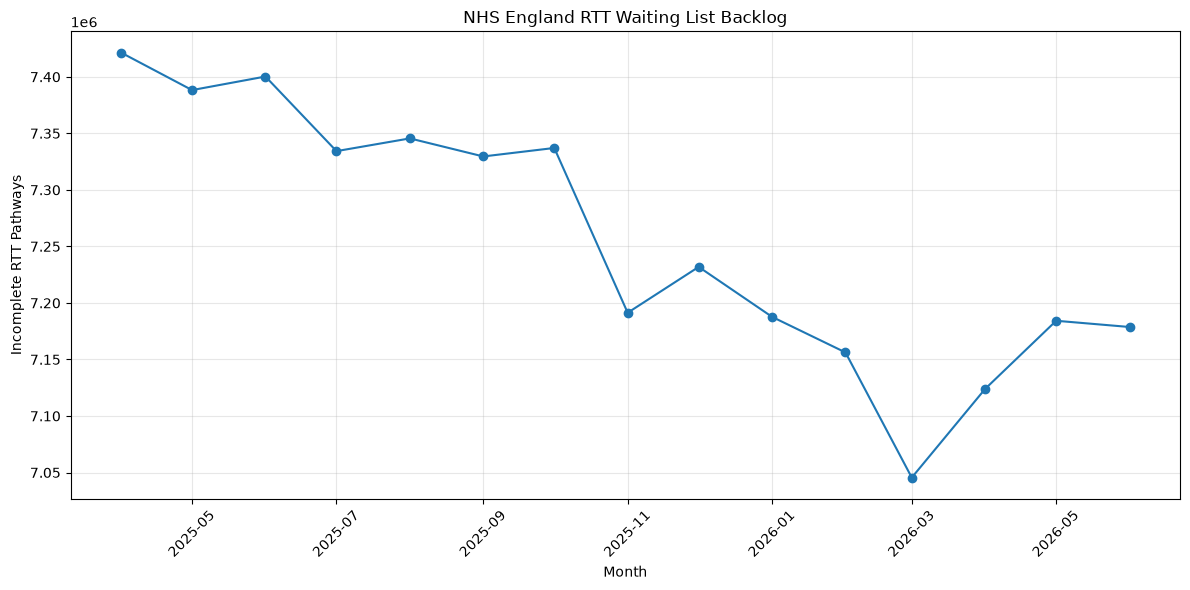

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    england_backlog["Date"],
    england_backlog["England_Backlog"],
    marker="o"
)

plt.title("NHS England RTT Waiting List Backlog")
plt.xlabel("Month")
plt.ylabel("Incomplete RTT Pathways")

plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

In [26]:
sample_full = pd.read_csv(
    all_files[-1],
    low_memory=False
)

waiting_time_cols = [
    col for col in sample_full.columns
    if "Weeks" in col
]

print("Number of waiting-time columns:", len(waiting_time_cols))

for col in waiting_time_cols:
    print(col)

Number of waiting-time columns: 105
Gt 00 To 01 Weeks SUM 1
Gt 01 To 02 Weeks SUM 1
Gt 02 To 03 Weeks SUM 1
Gt 03 To 04 Weeks SUM 1
Gt 04 To 05 Weeks SUM 1
Gt 05 To 06 Weeks SUM 1
Gt 06 To 07 Weeks SUM 1
Gt 07 To 08 Weeks SUM 1
Gt 08 To 09 Weeks SUM 1
Gt 09 To 10 Weeks SUM 1
Gt 10 To 11 Weeks SUM 1
Gt 11 To 12 Weeks SUM 1
Gt 12 To 13 Weeks SUM 1
Gt 13 To 14 Weeks SUM 1
Gt 14 To 15 Weeks SUM 1
Gt 15 To 16 Weeks SUM 1
Gt 16 To 17 Weeks SUM 1
Gt 17 To 18 Weeks SUM 1
Gt 18 To 19 Weeks SUM 1
Gt 19 To 20 Weeks SUM 1
Gt 20 To 21 Weeks SUM 1
Gt 21 To 22 Weeks SUM 1
Gt 22 To 23 Weeks SUM 1
Gt 23 To 24 Weeks SUM 1
Gt 24 To 25 Weeks SUM 1
Gt 25 To 26 Weeks SUM 1
Gt 26 To 27 Weeks SUM 1
Gt 27 To 28 Weeks SUM 1
Gt 28 To 29 Weeks SUM 1
Gt 29 To 30 Weeks SUM 1
Gt 30 To 31 Weeks SUM 1
Gt 31 To 32 Weeks SUM 1
Gt 32 To 33 Weeks SUM 1
Gt 33 To 34 Weeks SUM 1
Gt 34 To 35 Weeks SUM 1
Gt 35 To 36 Weeks SUM 1
Gt 36 To 37 Weeks SUM 1
Gt 37 To 38 Weeks SUM 1
Gt 38 To 39 Weeks SUM 1
Gt 39 To 40 Weeks SUM 1
Gt 4

In [27]:
part2_june = sample_full[
    sample_full["RTT Part Type"] == "Part_2"
].copy()

part2_june["Weekly_Bands_Sum"] = (
    part2_june[waiting_time_cols]
    .apply(pd.to_numeric, errors="coerce")
    .sum(axis=1)
)

check = part2_june[
    [
        "Weekly_Bands_Sum",
        "Total",
        "Patients with unknown clock start date",
        "Total All"
    ]
].copy()

display(check.head(20))

print("\nTotal rows:", len(check))

print(
    "Weekly bands equal Total:",
    (check["Weekly_Bands_Sum"] == check["Total"]).sum()
)

print(
    "Weekly bands + unknown equal Total All:",
    (
        check["Weekly_Bands_Sum"] +
        check["Patients with unknown clock start date"].fillna(0)
        == check["Total All"]
    ).sum()
)

,Weekly_Bands_Sum,Total,Patients with unknown clock start date,Total All
4,50.0,NaN,NaN,50
5,50.0,NaN,NaN,50
14,11.0,NaN,NaN,11
15,11.0,NaN,NaN,11
24,18.0,NaN,NaN,18
25,18.0,NaN,NaN,18
34,3.0,NaN,NaN,3
35,3.0,NaN,NaN,3
40,2.0,NaN,NaN,2
41,2.0,NaN,NaN,2



Total rows: 63355
Weekly bands equal Total: 0
Weekly bands + unknown equal Total All: 63355


In [28]:
def get_start_week(col):
    if col == "Gt 104 Weeks SUM 1":
        return 104
    return int(col.split()[1])

over_18_cols = [c for c in waiting_time_cols if get_start_week(c) >= 18]
over_52_cols = [c for c in waiting_time_cols if get_start_week(c) >= 52]
over_65_cols = [c for c in waiting_time_cols if get_start_week(c) >= 65]
over_104_cols = [c for c in waiting_time_cols if get_start_week(c) >= 104]

print("18+ columns:", len(over_18_cols))
print("52+ columns:", len(over_52_cols))
print("65+ columns:", len(over_65_cols))
print("104+ columns:", len(over_104_cols))

print("\nFirst 18+ column:", over_18_cols[0])
print("First 52+ column:", over_52_cols[0])
print("First 65+ column:", over_65_cols[0])
print("104+ column:", over_104_cols[0])

18+ columns: 87
52+ columns: 53
65+ columns: 40
104+ columns: 1

First 18+ column: Gt 18 To 19 Weeks SUM 1
First 52+ column: Gt 52 To 53 Weeks SUM 1
First 65+ column: Gt 65 To 66 Weeks SUM 1
104+ column: Gt 104 Weeks SUM 1


In [29]:
part2_june["Wait_18_Plus"] = (
    part2_june[over_18_cols]
    .apply(pd.to_numeric, errors="coerce")
    .sum(axis=1)
)

part2_june["Wait_52_Plus"] = (
    part2_june[over_52_cols]
    .apply(pd.to_numeric, errors="coerce")
    .sum(axis=1)
)

part2_june["Wait_65_Plus"] = (
    part2_june[over_65_cols]
    .apply(pd.to_numeric, errors="coerce")
    .sum(axis=1)
)

part2_june["Wait_104_Plus"] = (
    part2_june[over_104_cols]
    .apply(pd.to_numeric, errors="coerce")
    .sum(axis=1)
)

# Use C_999 only so specialties are not double-counted
june_total_rows = part2_june[
    part2_june["Treatment Function Code"] == "C_999"
]

print("June 2026 England waiting list:")
print(f"Total backlog: {june_total_rows['Total All'].sum():,.0f}")
print(f"18+ weeks:     {june_total_rows['Wait_18_Plus'].sum():,.0f}")
print(f"52+ weeks:     {june_total_rows['Wait_52_Plus'].sum():,.0f}")
print(f"65+ weeks:     {june_total_rows['Wait_65_Plus'].sum():,.0f}")
print(f"104+ weeks:    {june_total_rows['Wait_104_Plus'].sum():,.0f}")

June 2026 England waiting list:
Total backlog: 7,178,718
18+ weeks:     2,457,041
52+ weeks:     106,621
65+ weeks:     9,693
104+ weeks:    549


In [30]:
severity_parts = []

for file in all_files:
    temp = pd.read_csv(file, low_memory=False)

    # Keep incomplete pathways and the Total treatment-function rows
    temp = temp[
        (temp["RTT Part Type"] == "Part_2") &
        (temp["Treatment Function Code"] == "C_999")
    ].copy()

    temp["Wait_18_Plus"] = temp[over_18_cols].apply(
        pd.to_numeric, errors="coerce"
    ).sum(axis=1)

    temp["Wait_52_Plus"] = temp[over_52_cols].apply(
        pd.to_numeric, errors="coerce"
    ).sum(axis=1)

    temp["Wait_65_Plus"] = temp[over_65_cols].apply(
        pd.to_numeric, errors="coerce"
    ).sum(axis=1)

    temp["Wait_104_Plus"] = temp[over_104_cols].apply(
        pd.to_numeric, errors="coerce"
    ).sum(axis=1)

    severity_parts.append(
        temp[
            [
                "Period",
                "Total All",
                "Wait_18_Plus",
                "Wait_52_Plus",
                "Wait_65_Plus",
                "Wait_104_Plus"
            ]
        ]
    )

severity_df = pd.concat(severity_parts, ignore_index=True)

england_severity = (
    severity_df
    .groupby("Period", as_index=False)
    .sum()
)

print("Periods:", england_severity["Period"].nunique())
display(england_severity)

Periods: 15


,Period,Total All,Wait_18_Plus,Wait_52_Plus,Wait_65_Plus,Wait_104_Plus
0,RTT-April-2025,7421453,2991152.0,192560.0,10411.0,319.0
1,RTT-April-2026,7123980,2500575.0,100665.0,7702.0,576.0
2,RTT-August-2025,7345544,2869978.0,192024.0,14364.0,465.0
3,RTT-December-2025,7231880,2791286.0,142204.0,9393.0,611.0
4,RTT-February-2026,7156212,2683847.0,124280.0,8829.0,548.0
5,RTT-January-2026,7187677,2775530.0,137320.0,9522.0,576.0
6,RTT-July-2025,7334286,2847601.0,192769.0,13375.0,494.0
7,RTT-June-2025,7400275,2850184.0,194715.0,11820.0,371.0
8,RTT-June-2026,7178718,2457041.0,106621.0,9693.0,549.0
9,RTT-March-2026,7045510,2448888.0,95824.0,6304.0,499.0


In [31]:
england_severity["Date"] = pd.to_datetime(
    england_severity["Period"]
        .str.replace("RTT-", "", regex=False),
    format="%B-%Y"
)

england_severity = (
    england_severity
    .sort_values("Date")
    .reset_index(drop=True)
)

display(england_severity)

,Period,Total All,Wait_18_Plus,Wait_52_Plus,Wait_65_Plus,Wait_104_Plus,Date
0,RTT-April-2025,7421453,2991152.0,192560.0,10411.0,319.0,2025-04-01
1,RTT-May-2025,7388277,2889229.0,199590.0,12772.0,325.0,2025-05-01
2,RTT-June-2025,7400275,2850184.0,194715.0,11820.0,371.0,2025-06-01
3,RTT-July-2025,7334286,2847601.0,192769.0,13375.0,494.0,2025-07-01
4,RTT-August-2025,7345544,2869978.0,192024.0,14364.0,465.0,2025-08-01
5,RTT-September-2025,7329574,2806906.0,181947.0,14607.0,507.0,2025-09-01
6,RTT-October-2025,7337076,2813210.0,174373.0,14440.0,589.0,2025-10-01
7,RTT-November-2025,7191310,2761915.0,157710.0,11367.0,593.0,2025-11-01
8,RTT-December-2025,7231880,2791286.0,142204.0,9393.0,611.0,2025-12-01
9,RTT-January-2026,7187677,2775530.0,137320.0,9522.0,576.0,2026-01-01


In [32]:
england_severity["Pct_18_Plus"] = (
    england_severity["Wait_18_Plus"] /
    england_severity["Total All"] * 100
)

england_severity["Pct_52_Plus"] = (
    england_severity["Wait_52_Plus"] /
    england_severity["Total All"] * 100
)

england_severity["Pct_65_Plus"] = (
    england_severity["Wait_65_Plus"] /
    england_severity["Total All"] * 100
)

england_severity["Pct_104_Plus"] = (
    england_severity["Wait_104_Plus"] /
    england_severity["Total All"] * 100
)

display(
    england_severity[
        [
            "Date",
            "Pct_18_Plus",
            "Pct_52_Plus",
            "Pct_65_Plus",
            "Pct_104_Plus"
        ]
    ].round(3)
)

,Date,Pct_18_Plus,Pct_52_Plus,Pct_65_Plus,Pct_104_Plus
0,2025-04-01,40.304,2.595,0.140,0.004
1,2025-05-01,39.106,2.701,0.173,0.004
2,2025-06-01,38.515,2.631,0.160,0.005
3,2025-07-01,38.826,2.628,0.182,0.007
4,2025-08-01,39.071,2.614,0.196,0.006
5,2025-09-01,38.296,2.482,0.199,0.007
6,2025-10-01,38.342,2.377,0.197,0.008
7,2025-11-01,38.406,2.193,0.158,0.008
8,2025-12-01,38.597,1.966,0.130,0.008
9,2026-01-01,38.615,1.910,0.132,0.008


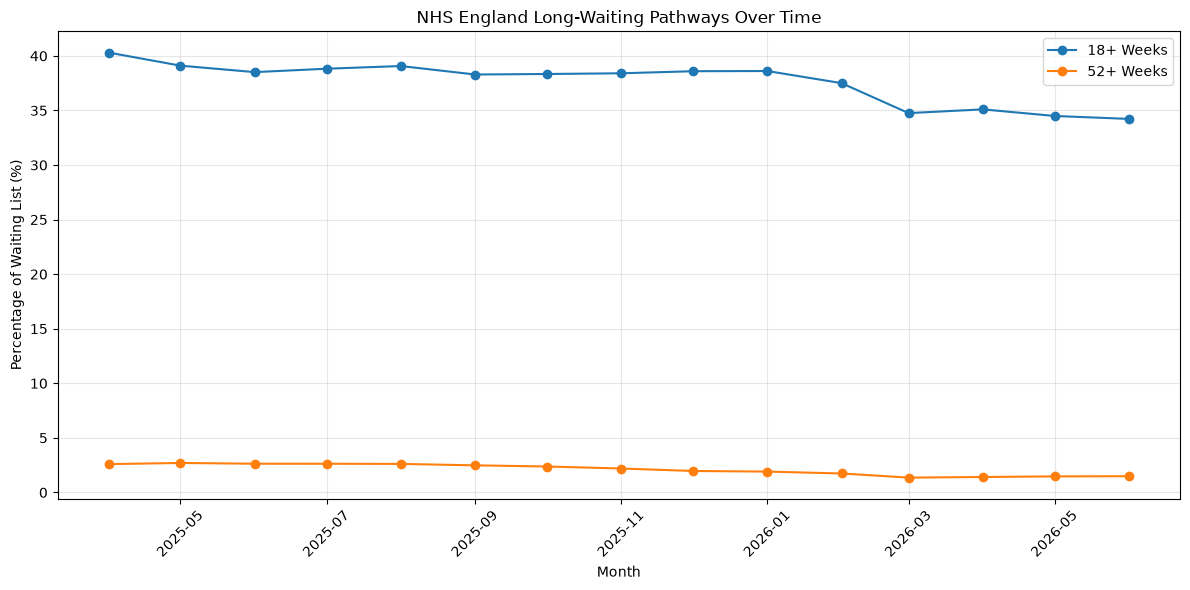

In [33]:
plt.figure(figsize=(12, 6))

plt.plot(
    england_severity["Date"],
    england_severity["Pct_18_Plus"],
    marker="o",
    label="18+ Weeks"
)

plt.plot(
    england_severity["Date"],
    england_severity["Pct_52_Plus"],
    marker="o",
    label="52+ Weeks"
)

plt.title("NHS England Long-Waiting Pathways Over Time")
plt.xlabel("Month")
plt.ylabel("Percentage of Waiting List (%)")

plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [34]:
june_provider_backlog = (
    provider_backlog[
        provider_backlog["Period"] == "RTT-June-2026"
    ]
    .sort_values("Total All", ascending=False)
    .reset_index(drop=True)
)

display(
    june_provider_backlog[
        [
            "Provider Org Code",
            "Provider Org Name",
            "Total All"
        ]
    ].head(15)
)

,Provider Org Code,Provider Org Name,Total All
0,R0A,MANCHESTER UNIVERSITY NHS FOUNDATION TRUST,166898
1,RAJ,MID AND SOUTH ESSEX NHS FOUNDATION TRUST,165626
2,RAL,ROYAL FREE LONDON NHS FOUNDATION TRUST,139530
3,RM3,NORTHERN CARE ALLIANCE NHS FOUNDATION TRUST,133909
4,R1H,BARTS HEALTH NHS TRUST,121533
5,RYR,UNIVERSITY HOSPITALS SUSSEX NHS FOUNDATION TRUST,116136
6,RWE,UNIVERSITY HOSPITALS OF LEICESTER NHS TRUST,115279
7,RJ1,GUY'S AND ST THOMAS' NHS FOUNDATION TRUST,110502
8,RTG,UNIVERSITY HOSPITALS OF DERBY AND BURTON NHS F...,96379
9,RRK,UNIVERSITY HOSPITALS BIRMINGHAM NHS FOUNDATION...,93337


In [35]:
provider_coverage = (
    provider_backlog
    .groupby(
        ["Provider Org Code", "Provider Org Name"]
    )["Period"]
    .nunique()
    .reset_index(name="Months_Available")
)

print("Total providers:", len(provider_coverage))

print("\nMonths available per provider:")
print(
    provider_coverage["Months_Available"]
    .value_counts()
    .sort_index()
)

print(
    "\nProviders present in all 15 months:",
    (provider_coverage["Months_Available"] == 15).sum()
)

Total providers: 559

Months available per provider:
Months_Available
1       5
2       4
3       5
4      24
5       3
6      12
7       7
8      22
9       7
10      7
11      4
12      6
13      3
14      3
15    447
Name: count, dtype: int64

Providers present in all 15 months: 447


In [36]:
complete_providers = provider_coverage[
    provider_coverage["Months_Available"] == 15
][
    ["Provider Org Code", "Provider Org Name"]
]

provider_panel = provider_backlog.merge(
    complete_providers,
    on=["Provider Org Code", "Provider Org Name"],
    how="inner"
)

print("Panel shape:", provider_panel.shape)
print("Providers:", provider_panel["Provider Org Code"].nunique())
print("Periods:", provider_panel["Period"].nunique())

print(
    "Expected rows:",
    len(complete_providers) * 15
)

Panel shape: (6705, 4)
Providers: 447
Periods: 15
Expected rows: 6705


In [37]:
provider_panel["Date"] = pd.to_datetime(
    provider_panel["Period"]
        .str.replace("RTT-", "", regex=False),
    format="%B-%Y"
)

provider_panel = (
    provider_panel
    .sort_values(
        ["Provider Org Code", "Provider Org Name", "Date"]
    )
    .reset_index(drop=True)
)

print("Shape:", provider_panel.shape)

display(
    provider_panel[
        [
            "Date",
            "Provider Org Code",
            "Provider Org Name",
            "Total All"
        ]
    ].head(20)
)

Shape: (6705, 5)


,Date,Provider Org Code,Provider Org Name,Total All
0,2025-04-01,A0C5S,SPAMEDICA GLOUCESTER,72
1,2025-05-01,A0C5S,SPAMEDICA GLOUCESTER,72
2,2025-06-01,A0C5S,SPAMEDICA GLOUCESTER,89
3,2025-07-01,A0C5S,SPAMEDICA GLOUCESTER,71
4,2025-08-01,A0C5S,SPAMEDICA GLOUCESTER,64
5,2025-09-01,A0C5S,SPAMEDICA GLOUCESTER,70
6,2025-10-01,A0C5S,SPAMEDICA GLOUCESTER,62
7,2025-11-01,A0C5S,SPAMEDICA GLOUCESTER,67
8,2025-12-01,A0C5S,SPAMEDICA GLOUCESTER,83
9,2026-01-01,A0C5S,SPAMEDICA GLOUCESTER,49


In [38]:
provider_panel["Backlog_Change"] = (
    provider_panel
    .groupby(["Provider Org Code", "Provider Org Name"])["Total All"]
    .diff()
)

provider_panel["Backlog_Change_Pct"] = (
    provider_panel
    .groupby(["Provider Org Code", "Provider Org Name"])["Total All"]
    .pct_change() * 100
)

display(
    provider_panel[
        [
            "Date",
            "Provider Org Code",
            "Provider Org Name",
            "Total All",
            "Backlog_Change",
            "Backlog_Change_Pct"
        ]
    ].head(20).round(2)
)

,Date,Provider Org Code,Provider Org Name,Total All,Backlog_Change,Backlog_Change_Pct
0,2025-04-01,A0C5S,SPAMEDICA GLOUCESTER,72,NaN,NaN
1,2025-05-01,A0C5S,SPAMEDICA GLOUCESTER,72,0.0,0.00
2,2025-06-01,A0C5S,SPAMEDICA GLOUCESTER,89,17.0,23.61
3,2025-07-01,A0C5S,SPAMEDICA GLOUCESTER,71,-18.0,-20.22
4,2025-08-01,A0C5S,SPAMEDICA GLOUCESTER,64,-7.0,-9.86
5,2025-09-01,A0C5S,SPAMEDICA GLOUCESTER,70,6.0,9.38
6,2025-10-01,A0C5S,SPAMEDICA GLOUCESTER,62,-8.0,-11.43
7,2025-11-01,A0C5S,SPAMEDICA GLOUCESTER,67,5.0,8.06
8,2025-12-01,A0C5S,SPAMEDICA GLOUCESTER,83,16.0,23.88
9,2026-01-01,A0C5S,SPAMEDICA GLOUCESTER,49,-34.0,-40.96


In [39]:
provider_panel["Backlog_Lag_1"] = (
    provider_panel
    .groupby("Provider Org Code")["Total All"]
    .shift(1)
)

provider_panel["Backlog_Lag_2"] = (
    provider_panel
    .groupby("Provider Org Code")["Total All"]
    .shift(2)
)

provider_panel["Backlog_Lag_3"] = (
    provider_panel
    .groupby("Provider Org Code")["Total All"]
    .shift(3)
)

display(
    provider_panel[
        [
            "Date",
            "Provider Org Code",
            "Provider Org Name",
            "Total All",
            "Backlog_Lag_1",
            "Backlog_Lag_2",
            "Backlog_Lag_3"
        ]
    ].head(20)
)

,Date,Provider Org Code,Provider Org Name,Total All,Backlog_Lag_1,Backlog_Lag_2,Backlog_Lag_3
0,2025-04-01,A0C5S,SPAMEDICA GLOUCESTER,72,NaN,NaN,NaN
1,2025-05-01,A0C5S,SPAMEDICA GLOUCESTER,72,72.0,NaN,NaN
2,2025-06-01,A0C5S,SPAMEDICA GLOUCESTER,89,72.0,72.0,NaN
3,2025-07-01,A0C5S,SPAMEDICA GLOUCESTER,71,89.0,72.0,72.0
4,2025-08-01,A0C5S,SPAMEDICA GLOUCESTER,64,71.0,89.0,72.0
5,2025-09-01,A0C5S,SPAMEDICA GLOUCESTER,70,64.0,71.0,89.0
6,2025-10-01,A0C5S,SPAMEDICA GLOUCESTER,62,70.0,64.0,71.0
7,2025-11-01,A0C5S,SPAMEDICA GLOUCESTER,67,62.0,70.0,64.0
8,2025-12-01,A0C5S,SPAMEDICA GLOUCESTER,83,67.0,62.0,70.0
9,2026-01-01,A0C5S,SPAMEDICA GLOUCESTER,49,83.0,67.0,62.0


In [40]:
provider_panel["Target_Next_Month_Backlog"] = (
    provider_panel
    .groupby("Provider Org Code")["Total All"]
    .shift(-1)
)

display(
    provider_panel[
        [
            "Date",
            "Provider Org Code",
            "Provider Org Name",
            "Total All",
            "Backlog_Lag_1",
            "Backlog_Lag_2",
            "Backlog_Lag_3",
            "Target_Next_Month_Backlog"
        ]
    ].head(20)
)

,Date,Provider Org Code,Provider Org Name,Total All,Backlog_Lag_1,Backlog_Lag_2,Backlog_Lag_3,Target_Next_Month_Backlog
0,2025-04-01,A0C5S,SPAMEDICA GLOUCESTER,72,NaN,NaN,NaN,72.0
1,2025-05-01,A0C5S,SPAMEDICA GLOUCESTER,72,72.0,NaN,NaN,89.0
2,2025-06-01,A0C5S,SPAMEDICA GLOUCESTER,89,72.0,72.0,NaN,71.0
3,2025-07-01,A0C5S,SPAMEDICA GLOUCESTER,71,89.0,72.0,72.0,64.0
4,2025-08-01,A0C5S,SPAMEDICA GLOUCESTER,64,71.0,89.0,72.0,70.0
5,2025-09-01,A0C5S,SPAMEDICA GLOUCESTER,70,64.0,71.0,89.0,62.0
6,2025-10-01,A0C5S,SPAMEDICA GLOUCESTER,62,70.0,64.0,71.0,67.0
7,2025-11-01,A0C5S,SPAMEDICA GLOUCESTER,67,62.0,70.0,64.0,83.0
8,2025-12-01,A0C5S,SPAMEDICA GLOUCESTER,83,67.0,62.0,70.0,49.0
9,2026-01-01,A0C5S,SPAMEDICA GLOUCESTER,49,83.0,67.0,62.0,68.0


In [41]:
model_df = provider_panel.dropna(
    subset=[
        "Backlog_Lag_1",
        "Backlog_Lag_2",
        "Backlog_Lag_3",
        "Target_Next_Month_Backlog"
    ]
).copy()

print("Model dataset shape:", model_df.shape)
print("Providers:", model_df["Provider Org Code"].nunique())
print("Dates:", model_df["Date"].nunique())

print("\nDate range:")
print("Start:", model_df["Date"].min())
print("End:", model_df["Date"].max())

display(model_df.head())

Model dataset shape: (4917, 11)
Providers: 447
Dates: 11

Date range:
Start: 2025-07-01 00:00:00
End: 2026-05-01 00:00:00


,Period,Provider Org Code,Provider Org Name,Total All,Date,Backlog_Change,Backlog_Change_Pct,Backlog_Lag_1,Backlog_Lag_2,Backlog_Lag_3,Target_Next_Month_Backlog
3,RTT-July-2025,A0C5S,SPAMEDICA GLOUCESTER,71,2025-07-01,-18.0,-20.224719,89.0,72.0,72.0,64.0
4,RTT-August-2025,A0C5S,SPAMEDICA GLOUCESTER,64,2025-08-01,-7.0,-9.859155,71.0,89.0,72.0,70.0
5,RTT-September-2025,A0C5S,SPAMEDICA GLOUCESTER,70,2025-09-01,6.0,9.375000,64.0,71.0,89.0,62.0
6,RTT-October-2025,A0C5S,SPAMEDICA GLOUCESTER,62,2025-10-01,-8.0,-11.428571,70.0,64.0,71.0,67.0
7,RTT-November-2025,A0C5S,SPAMEDICA GLOUCESTER,67,2025-11-01,5.0,8.064516,62.0,70.0,64.0,83.0


In [42]:
rows_per_month = (
    model_df
    .groupby("Date")
    .size()
    .reset_index(name="Rows")
)

display(rows_per_month)

,Date,Rows
0,2025-07-01,447
1,2025-08-01,447
2,2025-09-01,447
3,2025-10-01,447
4,2025-11-01,447
5,2025-12-01,447
6,2026-01-01,447
7,2026-02-01,447
8,2026-03-01,447
9,2026-04-01,447


In [43]:
train_df = model_df[
    model_df["Date"] <= "2026-03-01"
].copy()

test_df = model_df[
    model_df["Date"] >= "2026-04-01"
].copy()

print("TRAIN")
print("Shape:", train_df.shape)
print("Start:", train_df["Date"].min())
print("End:", train_df["Date"].max())

print("\nTEST")
print("Shape:", test_df.shape)
print("Start:", test_df["Date"].min())
print("End:", test_df["Date"].max())

TRAIN
Shape: (4023, 11)
Start: 2025-07-01 00:00:00
End: 2026-03-01 00:00:00

TEST
Shape: (894, 11)
Start: 2026-04-01 00:00:00
End: 2026-05-01 00:00:00


In [44]:
features = [
    "Total All",
    "Backlog_Lag_1",
    "Backlog_Lag_2",
    "Backlog_Lag_3"
]

target = "Target_Next_Month_Backlog"

X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

print("\nFeatures:")
print(X_train.columns.tolist())

print("\nMissing values:")
print("X_train:", X_train.isna().sum().sum())
print("X_test:", X_test.isna().sum().sum())
print("y_train:", y_train.isna().sum())
print("y_test:", y_test.isna().sum())

X_train: (4023, 4)
y_train: (4023,)
X_test: (894, 4)
y_test: (894,)

Features:
['Total All', 'Backlog_Lag_1', 'Backlog_Lag_2', 'Backlog_Lag_3']

Missing values:
X_train: 0
X_test: 0
y_train: 0
y_test: 0


In [45]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Naive forecast:
# predict next month's backlog = current month's backlog
baseline_pred = X_test["Total All"]

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_r2 = r2_score(y_test, baseline_pred)

print("NAIVE BASELINE RESULTS")
print("----------------------")
print(f"MAE:  {baseline_mae:,.2f}")
print(f"RMSE: {baseline_rmse:,.2f}")
print(f"R²:   {baseline_r2:.4f}")

NAIVE BASELINE RESULTS
----------------------
MAE:  260.77
RMSE: 572.60
R²:   0.9996


In [46]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)

linear_mae = mean_absolute_error(y_test, linear_pred)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_pred))
linear_r2 = r2_score(y_test, linear_pred)

print("LINEAR REGRESSION RESULTS")
print("-------------------------")
print(f"MAE:  {linear_mae:,.2f}")
print(f"RMSE: {linear_rmse:,.2f}")
print(f"R²:   {linear_r2:.4f}")

LINEAR REGRESSION RESULTS
-------------------------
MAE:  276.89
RMSE: 604.56
R²:   0.9995


In [47]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("RANDOM FOREST RESULTS")
print("---------------------")
print(f"MAE:  {rf_mae:,.2f}")
print(f"RMSE: {rf_rmse:,.2f}")
print(f"R²:   {rf_r2:.4f}")

RANDOM FOREST RESULTS
---------------------
MAE:  324.83
RMSE: 765.69
R²:   0.9993


In [48]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_r2 = r2_score(y_test, xgb_pred)

print("XGBOOST RESULTS")
print("----------------")
print(f"MAE:  {xgb_mae:,.2f}")
print(f"RMSE: {xgb_rmse:,.2f}")
print(f"R²:   {xgb_r2:.4f}")

XGBOOST RESULTS
----------------
MAE:  452.47
RMSE: 1,460.39
R²:   0.9973


In [49]:
part_counts = []

for file in all_files:
    temp = pd.read_csv(
        file,
        usecols=["Period", "RTT Part Type", "RTT Part Description"],
        low_memory=False
    )

    counts = (
        temp.groupby(
            ["Period", "RTT Part Type", "RTT Part Description"]
        )
        .size()
        .reset_index(name="Rows")
    )

    part_counts.append(counts)

part_counts_df = pd.concat(part_counts, ignore_index=True)

display(
    part_counts_df.sort_values(
        ["Period", "RTT Part Type"]
    )
)

,Period,RTT Part Type,RTT Part Description,Rows
0,RTT-April-2025,Part_1A,Completed Pathways For Admitted Patients,19266
1,RTT-April-2025,Part_1B,Completed Pathways For Non-Admitted Patients,31744
2,RTT-April-2025,Part_2,Incomplete Pathways,65638
3,RTT-April-2025,Part_2A,Incomplete Pathways with DTA,30584
4,RTT-April-2025,Part_3,New RTT Periods - All Patients,36503
...,...,...,...,...
25,RTT-September-2025,Part_1A,Completed Pathways For Admitted Patients,19128
26,RTT-September-2025,Part_1B,Completed Pathways For Non-Admitted Patients,32731
27,RTT-September-2025,Part_2,Incomplete Pathways,64994
28,RTT-September-2025,Part_2A,Incomplete Pathways with DTA,30235


In [50]:
demand_list = []

for file in all_files:
    temp = pd.read_csv(
        file,
        usecols=[
            "Period",
            "Provider Org Code",
            "Provider Org Name",
            "RTT Part Type",
            "Total All"
        ],
        low_memory=False
    )

    temp = temp[temp["RTT Part Type"] == "Part_3"]

    temp = (
        temp.groupby(
            ["Period", "Provider Org Code", "Provider Org Name"],
            as_index=False
        )["Total All"]
        .sum()
    )

    temp = temp.rename(columns={"Total All": "New_RTT_Periods"})

    demand_list.append(temp)

provider_demand = pd.concat(demand_list, ignore_index=True)

print("Shape:", provider_demand.shape)
print("Periods:", provider_demand["Period"].nunique())
print("Providers:", provider_demand["Provider Org Code"].nunique())

display(provider_demand.head(10))

Shape: (7384, 4)
Periods: 15
Providers: 547


,Period,Provider Org Code,Provider Org Name,New_RTT_Periods
0,RTT-April-2025,A0C5S,SPAMEDICA GLOUCESTER,156
1,RTT-April-2025,A1D1B,SPAMEDICA WEMBLEY,34
2,RTT-April-2025,A1U4J,SPAMEDICA PORTSMOUTH,132
3,RTT-April-2025,A4M8P,BUCKSHAW HOSPITAL,1272
4,RTT-April-2025,A4Q9X,NEWMEDICA LEICESTER,636
5,RTT-April-2025,AAH,TETBURY HOSPITAL TRUST LTD,830
6,RTT-April-2025,AAV,COMMUNITY HEALTH AND EYECARE LIMITED,5660
7,RTT-April-2025,ACG08,NEWMEDICA OPHTHALMOLOGY - NUNEATON - CAMP HILL...,62
8,RTT-April-2025,ACG12,NEWMEDICA COMMUNITY OPHTHALMOLOGY - NORTH EAST...,836
9,RTT-April-2025,ACG13,NEWMEDICA - GLOUCESTER (ASPEN MEDICAL CENTRE),212


In [51]:
completion_list = []

for file in all_files:
    temp = pd.read_csv(
        file,
        usecols=[
            "Period",
            "Provider Org Code",
            "Provider Org Name",
            "RTT Part Type",
            "Total All"
        ],
        low_memory=False
    )

    temp = temp[
        temp["RTT Part Type"].isin(["Part_1A", "Part_1B"])
    ]

    temp = (
        temp.groupby(
            ["Period", "Provider Org Code", "Provider Org Name"],
            as_index=False
        )["Total All"]
        .sum()
    )

    temp = temp.rename(
        columns={"Total All": "Completed_RTT_Pathways"}
    )

    completion_list.append(temp)

provider_completions = pd.concat(
    completion_list,
    ignore_index=True
)

print("Shape:", provider_completions.shape)
print("Periods:", provider_completions["Period"].nunique())
print(
    "Providers:",
    provider_completions["Provider Org Code"].nunique()
)

display(provider_completions.head(10))

Shape: (7365, 4)
Periods: 15
Providers: 537


,Period,Provider Org Code,Provider Org Name,Completed_RTT_Pathways
0,RTT-April-2025,A0C5S,SPAMEDICA GLOUCESTER,254
1,RTT-April-2025,A1D1B,SPAMEDICA WEMBLEY,4
2,RTT-April-2025,A1U4J,SPAMEDICA PORTSMOUTH,144
3,RTT-April-2025,A4M8P,BUCKSHAW HOSPITAL,674
4,RTT-April-2025,A4Q9X,NEWMEDICA LEICESTER,622
5,RTT-April-2025,AAH,TETBURY HOSPITAL TRUST LTD,912
6,RTT-April-2025,AAV,COMMUNITY HEALTH AND EYECARE LIMITED,5220
7,RTT-April-2025,ACG08,NEWMEDICA OPHTHALMOLOGY - NUNEATON - CAMP HILL...,76
8,RTT-April-2025,ACG12,NEWMEDICA COMMUNITY OPHTHALMOLOGY - NORTH EAST...,998
9,RTT-April-2025,ACG13,NEWMEDICA - GLOUCESTER (ASPEN MEDICAL CENTRE),164


In [52]:
provider_flow = provider_demand.merge(
    provider_completions,
    on=[
        "Period",
        "Provider Org Code",
        "Provider Org Name"
    ],
    how="outer"
)

print("Shape:", provider_flow.shape)
print("Periods:", provider_flow["Period"].nunique())
print("Providers:", provider_flow["Provider Org Code"].nunique())

print("\nMissing values:")
print(provider_flow[[
    "New_RTT_Periods",
    "Completed_RTT_Pathways"
]].isna().sum())

display(provider_flow.head(10))

Shape: (7442, 5)
Periods: 15
Providers: 549

Missing values:
New_RTT_Periods           58
Completed_RTT_Pathways    77
dtype: int64


,Period,Provider Org Code,Provider Org Name,New_RTT_Periods,Completed_RTT_Pathways
0,RTT-April-2025,A0C5S,SPAMEDICA GLOUCESTER,156.0,254.0
1,RTT-April-2025,A1D1B,SPAMEDICA WEMBLEY,34.0,4.0
2,RTT-April-2025,A1U4J,SPAMEDICA PORTSMOUTH,132.0,144.0
3,RTT-April-2025,A4M8P,BUCKSHAW HOSPITAL,1272.0,674.0
4,RTT-April-2025,A4Q9X,NEWMEDICA LEICESTER,636.0,622.0
5,RTT-April-2025,AAH,TETBURY HOSPITAL TRUST LTD,830.0,912.0
6,RTT-April-2025,AAV,COMMUNITY HEALTH AND EYECARE LIMITED,5660.0,5220.0
7,RTT-April-2025,ACG08,NEWMEDICA OPHTHALMOLOGY - NUNEATON - CAMP HILL...,62.0,76.0
8,RTT-April-2025,ACG12,NEWMEDICA COMMUNITY OPHTHALMOLOGY - NORTH EAST...,836.0,998.0
9,RTT-April-2025,ACG13,NEWMEDICA - GLOUCESTER (ASPEN MEDICAL CENTRE),212.0,164.0


In [53]:
stable_provider_codes = provider_panel[
    "Provider Org Code"
].unique()

stable_flow = provider_flow[
    provider_flow["Provider Org Code"].isin(stable_provider_codes)
].copy()

print("Stable providers:", stable_flow["Provider Org Code"].nunique())
print("Rows:", stable_flow.shape[0])

print("\nMissing values among stable providers:")
print(
    stable_flow[
        ["New_RTT_Periods", "Completed_RTT_Pathways"]
    ].isna().sum()
)

Stable providers: 447
Rows: 6705

Missing values among stable providers:
New_RTT_Periods           33
Completed_RTT_Pathways    19
dtype: int64


In [54]:
missing_flow = stable_flow[
    stable_flow["New_RTT_Periods"].isna()
    | stable_flow["Completed_RTT_Pathways"].isna()
].copy()

print("Provider-months with missing flow data:", len(missing_flow))
print(
    "Affected providers:",
    missing_flow["Provider Org Code"].nunique()
)

display(
    missing_flow.sort_values(
        ["Provider Org Code", "Period"]
    )
)

Provider-months with missing flow data: 52
Affected providers: 7


,Period,Provider Org Code,Provider Org Name,New_RTT_Periods,Completed_RTT_Pathways
58,RTT-April-2025,GEC01,RAPID INVESTIGATION SERVICE,NaN,372.0
546,RTT-April-2026,GEC01,RAPID INVESTIGATION SERVICE,NaN,356.0
1055,RTT-August-2025,GEC01,RAPID INVESTIGATION SERVICE,NaN,454.0
1536,RTT-December-2025,GEC01,RAPID INVESTIGATION SERVICE,NaN,424.0
2038,RTT-February-2026,GEC01,RAPID INVESTIGATION SERVICE,NaN,402.0
2548,RTT-January-2026,GEC01,RAPID INVESTIGATION SERVICE,NaN,374.0
3052,RTT-July-2025,GEC01,RAPID INVESTIGATION SERVICE,NaN,380.0
3525,RTT-June-2025,GEC01,RAPID INVESTIGATION SERVICE,NaN,384.0
4016,RTT-June-2026,GEC01,RAPID INVESTIGATION SERVICE,NaN,494.0
4542,RTT-March-2026,GEC01,RAPID INVESTIGATION SERVICE,NaN,398.0


In [55]:
affected_providers = (
    missing_flow[
        ["Provider Org Code", "Provider Org Name"]
    ]
    .drop_duplicates()
    .sort_values("Provider Org Code")
)

display(affected_providers)

print(
    "Affected provider codes:",
    affected_providers["Provider Org Code"].tolist()
)

,Provider Org Code,Provider Org Name
58,GEC01,RAPID INVESTIGATION SERVICE
66,J0M7P,SPAMEDICA HEREFORD DIAGNOSTIC AND TREATMENT CE...
98,NLG,COMMUNITAS CLINICS
2126,NT204,"NUFFIELD HEALTH, BRENTWOOD HOSPITAL"
5132,NT211,"NUFFIELD HEALTH, CHELTENHAM HOSPITAL"
226,NT445,EDGBASTON HOSPITAL
297,Q2Y5H,OVIVA UK LTD


Affected provider codes: ['GEC01', 'J0M7P', 'NLG', 'NT204', 'NT211', 'NT445', 'Q2Y5H']


In [56]:
affected_codes = affected_providers[
    "Provider Org Code"
].tolist()

clean_flow = stable_flow[
    ~stable_flow["Provider Org Code"].isin(affected_codes)
].copy()

print("Clean providers:", clean_flow["Provider Org Code"].nunique())
print("Periods:", clean_flow["Period"].nunique())
print("Rows:", clean_flow.shape[0])

print("\nExpected rows:", 440 * 15)

print("\nMissing values:")
print(
    clean_flow[
        ["New_RTT_Periods", "Completed_RTT_Pathways"]
    ].isna().sum()
)

Clean providers: 440
Periods: 15
Rows: 6600

Expected rows: 6600

Missing values:
New_RTT_Periods           0
Completed_RTT_Pathways    0
dtype: int64


In [57]:
digital_twin_df = provider_panel.merge(
    clean_flow[
        [
            "Period",
            "Provider Org Code",
            "New_RTT_Periods",
            "Completed_RTT_Pathways"
        ]
    ],
    on=["Period", "Provider Org Code"],
    how="inner"
)

print("Shape:", digital_twin_df.shape)
print("Providers:", digital_twin_df["Provider Org Code"].nunique())
print("Periods:", digital_twin_df["Period"].nunique())

print("\nMissing values:")
print(
    digital_twin_df[
        [
            "Total All",
            "New_RTT_Periods",
            "Completed_RTT_Pathways"
        ]
    ].isna().sum()
)

display(
    digital_twin_df[
        [
            "Date",
            "Provider Org Code",
            "Provider Org Name",
            "Total All",
            "New_RTT_Periods",
            "Completed_RTT_Pathways"
        ]
    ].head(10)
)

Shape: (6600, 13)
Providers: 440
Periods: 15

Missing values:
Total All                 0
New_RTT_Periods           0
Completed_RTT_Pathways    0
dtype: int64


,Date,Provider Org Code,Provider Org Name,Total All,New_RTT_Periods,Completed_RTT_Pathways
0,2025-04-01,A0C5S,SPAMEDICA GLOUCESTER,72,156.0,254.0
1,2025-05-01,A0C5S,SPAMEDICA GLOUCESTER,72,172.0,238.0
2,2025-06-01,A0C5S,SPAMEDICA GLOUCESTER,89,152.0,192.0
3,2025-07-01,A0C5S,SPAMEDICA GLOUCESTER,71,126.0,184.0
4,2025-08-01,A0C5S,SPAMEDICA GLOUCESTER,64,106.0,178.0
5,2025-09-01,A0C5S,SPAMEDICA GLOUCESTER,70,118.0,188.0
6,2025-10-01,A0C5S,SPAMEDICA GLOUCESTER,62,102.0,162.0
7,2025-11-01,A0C5S,SPAMEDICA GLOUCESTER,67,82.0,134.0
8,2025-12-01,A0C5S,SPAMEDICA GLOUCESTER,83,106.0,160.0
9,2026-01-01,A0C5S,SPAMEDICA GLOUCESTER,49,86.0,160.0


In [58]:
digital_twin_df["Net_Flow"] = (
    digital_twin_df["New_RTT_Periods"]
    - digital_twin_df["Completed_RTT_Pathways"]
)

print(digital_twin_df["Net_Flow"].describe())

display(
    digital_twin_df[
        [
            "Date",
            "Provider Org Code",
            "Provider Org Name",
            "Total All",
            "New_RTT_Periods",
            "Completed_RTT_Pathways",
            "Net_Flow"
        ]
    ].head(10)
)

count     6600.000000
mean      1069.452121
std       2702.430621
min     -10384.000000
25%        -62.000000
50%         60.000000
75%        866.500000
max      23000.000000
Name: Net_Flow, dtype: float64


,Date,Provider Org Code,Provider Org Name,Total All,New_RTT_Periods,Completed_RTT_Pathways,Net_Flow
0,2025-04-01,A0C5S,SPAMEDICA GLOUCESTER,72,156.0,254.0,-98.0
1,2025-05-01,A0C5S,SPAMEDICA GLOUCESTER,72,172.0,238.0,-66.0
2,2025-06-01,A0C5S,SPAMEDICA GLOUCESTER,89,152.0,192.0,-40.0
3,2025-07-01,A0C5S,SPAMEDICA GLOUCESTER,71,126.0,184.0,-58.0
4,2025-08-01,A0C5S,SPAMEDICA GLOUCESTER,64,106.0,178.0,-72.0
5,2025-09-01,A0C5S,SPAMEDICA GLOUCESTER,70,118.0,188.0,-70.0
6,2025-10-01,A0C5S,SPAMEDICA GLOUCESTER,62,102.0,162.0,-60.0
7,2025-11-01,A0C5S,SPAMEDICA GLOUCESTER,67,82.0,134.0,-52.0
8,2025-12-01,A0C5S,SPAMEDICA GLOUCESTER,83,106.0,160.0,-54.0
9,2026-01-01,A0C5S,SPAMEDICA GLOUCESTER,49,86.0,160.0,-74.0


In [59]:
digital_twin_df = digital_twin_df.sort_values(
    ["Provider Org Code", "Date"]
).copy()

digital_twin_df["Actual_Backlog_Change"] = (
    digital_twin_df.groupby("Provider Org Code")["Total All"].diff()
)

flow_check = digital_twin_df.dropna(
    subset=["Actual_Backlog_Change"]
).copy()

correlation = flow_check[
    ["Net_Flow", "Actual_Backlog_Change"]
].corr().iloc[0, 1]

print("Correlation between Net Flow and Actual Backlog Change:")
print(round(correlation, 4))

print("\nComparison:")
display(
    flow_check[
        [
            "Date",
            "Provider Org Code",
            "Provider Org Name",
            "Net_Flow",
            "Actual_Backlog_Change"
        ]
    ].head(15)
)

Correlation between Net Flow and Actual Backlog Change:
0.0496

Comparison:


,Date,Provider Org Code,Provider Org Name,Net_Flow,Actual_Backlog_Change
1,2025-05-01,A0C5S,SPAMEDICA GLOUCESTER,-66.0,0.0
2,2025-06-01,A0C5S,SPAMEDICA GLOUCESTER,-40.0,17.0
3,2025-07-01,A0C5S,SPAMEDICA GLOUCESTER,-58.0,-18.0
4,2025-08-01,A0C5S,SPAMEDICA GLOUCESTER,-72.0,-7.0
5,2025-09-01,A0C5S,SPAMEDICA GLOUCESTER,-70.0,6.0
6,2025-10-01,A0C5S,SPAMEDICA GLOUCESTER,-60.0,-8.0
7,2025-11-01,A0C5S,SPAMEDICA GLOUCESTER,-52.0,5.0
8,2025-12-01,A0C5S,SPAMEDICA GLOUCESTER,-54.0,16.0
9,2026-01-01,A0C5S,SPAMEDICA GLOUCESTER,-74.0,-34.0
10,2026-02-01,A0C5S,SPAMEDICA GLOUCESTER,-82.0,19.0


In [60]:
digital_twin_df["Target_Next_Month_Backlog"] = (
    digital_twin_df
    .groupby("Provider Org Code")["Total All"]
    .shift(-1)
)

forecast_df = digital_twin_df.dropna(
    subset=["Target_Next_Month_Backlog"]
).copy()

print("Shape:", forecast_df.shape)
print("Providers:", forecast_df["Provider Org Code"].nunique())
print("Dates:", forecast_df["Date"].nunique())

print("Start:", forecast_df["Date"].min())
print("End:", forecast_df["Date"].max())

display(
    forecast_df[
        [
            "Date",
            "Provider Org Code",
            "Total All",
            "New_RTT_Periods",
            "Completed_RTT_Pathways",
            "Net_Flow",
            "Target_Next_Month_Backlog"
        ]
    ].head(10)
)

Shape: (6160, 15)
Providers: 440
Dates: 14
Start: 2025-04-01 00:00:00
End: 2026-05-01 00:00:00


,Date,Provider Org Code,Total All,New_RTT_Periods,Completed_RTT_Pathways,Net_Flow,Target_Next_Month_Backlog
0,2025-04-01,A0C5S,72,156.0,254.0,-98.0,72.0
1,2025-05-01,A0C5S,72,172.0,238.0,-66.0,89.0
2,2025-06-01,A0C5S,89,152.0,192.0,-40.0,71.0
3,2025-07-01,A0C5S,71,126.0,184.0,-58.0,64.0
4,2025-08-01,A0C5S,64,106.0,178.0,-72.0,70.0
5,2025-09-01,A0C5S,70,118.0,188.0,-70.0,62.0
6,2025-10-01,A0C5S,62,102.0,162.0,-60.0,67.0
7,2025-11-01,A0C5S,67,82.0,134.0,-52.0,83.0
8,2025-12-01,A0C5S,83,106.0,160.0,-54.0,49.0
9,2026-01-01,A0C5S,49,86.0,160.0,-74.0,68.0


In [61]:
flow_train = forecast_df[
    forecast_df["Date"] <= "2026-03-01"
].copy()

flow_test = forecast_df[
    forecast_df["Date"] >= "2026-04-01"
].copy()

print("TRAIN")
print("Shape:", flow_train.shape)
print("Start:", flow_train["Date"].min())
print("End:", flow_train["Date"].max())

print("\nTEST")
print("Shape:", flow_test.shape)
print("Start:", flow_test["Date"].min())
print("End:", flow_test["Date"].max())

print("\nProviders in train:", flow_train["Provider Org Code"].nunique())
print("Providers in test:", flow_test["Provider Org Code"].nunique())

TRAIN
Shape: (5280, 15)
Start: 2025-04-01 00:00:00
End: 2026-03-01 00:00:00

TEST
Shape: (880, 15)
Start: 2026-04-01 00:00:00
End: 2026-05-01 00:00:00

Providers in train: 440
Providers in test: 440


In [62]:
flow_features = [
    "Total All",
    "New_RTT_Periods",
    "Completed_RTT_Pathways",
    "Net_Flow"
]

flow_target = "Target_Next_Month_Backlog"

X_flow_train = flow_train[flow_features]
y_flow_train = flow_train[flow_target]

X_flow_test = flow_test[flow_features]
y_flow_test = flow_test[flow_target]

print("X_train:", X_flow_train.shape)
print("y_train:", y_flow_train.shape)

print("X_test:", X_flow_test.shape)
print("y_test:", y_flow_test.shape)

print("\nFeatures:")
print(X_flow_train.columns.tolist())

print("\nMissing values:")
print("X_train:", X_flow_train.isna().sum().sum())
print("X_test:", X_flow_test.isna().sum().sum())
print("y_train:", y_flow_train.isna().sum())
print("y_test:", y_flow_test.isna().sum())

X_train: (5280, 4)
y_train: (5280,)
X_test: (880, 4)
y_test: (880,)

Features:
['Total All', 'New_RTT_Periods', 'Completed_RTT_Pathways', 'Net_Flow']

Missing values:
X_train: 0
X_test: 0
y_train: 0
y_test: 0


In [63]:
flow_baseline_pred = X_flow_test["Total All"]

flow_baseline_mae = mean_absolute_error(
    y_flow_test,
    flow_baseline_pred
)

flow_baseline_rmse = np.sqrt(
    mean_squared_error(
        y_flow_test,
        flow_baseline_pred
    )
)

flow_baseline_r2 = r2_score(
    y_flow_test,
    flow_baseline_pred
)

print("FLOW DATASET - NAIVE BASELINE")
print("-----------------------------")
print(f"MAE:  {flow_baseline_mae:,.2f}")
print(f"RMSE: {flow_baseline_rmse:,.2f}")
print(f"R²:   {flow_baseline_r2:.4f}")

FLOW DATASET - NAIVE BASELINE
-----------------------------
MAE:  261.70
RMSE: 574.90
R²:   0.9996


In [64]:
from sklearn.linear_model import LinearRegression

flow_linear_model = LinearRegression()

flow_linear_model.fit(
    X_flow_train,
    y_flow_train
)

flow_linear_pred = flow_linear_model.predict(
    X_flow_test
)

flow_linear_mae = mean_absolute_error(
    y_flow_test,
    flow_linear_pred
)

flow_linear_rmse = np.sqrt(
    mean_squared_error(
        y_flow_test,
        flow_linear_pred
    )
)

flow_linear_r2 = r2_score(
    y_flow_test,
    flow_linear_pred
)

print("FLOW LINEAR REGRESSION")
print("----------------------")
print(f"MAE:  {flow_linear_mae:,.2f}")
print(f"RMSE: {flow_linear_rmse:,.2f}")
print(f"R²:   {flow_linear_r2:.4f}")

FLOW LINEAR REGRESSION
----------------------
MAE:  269.96
RMSE: 581.28
R²:   0.9996


In [65]:
digital_twin_df = digital_twin_df.sort_values(
    ["Provider Org Code", "Date"]
).copy()

for lag in [1, 2, 3]:
    digital_twin_df[f"Backlog_Lag_{lag}"] = (
        digital_twin_df
        .groupby("Provider Org Code")["Total All"]
        .shift(lag)
    )

print(
    digital_twin_df[
        [
            "Total All",
            "Backlog_Lag_1",
            "Backlog_Lag_2",
            "Backlog_Lag_3"
        ]
    ].isna().sum()
)

display(
    digital_twin_df[
        [
            "Date",
            "Provider Org Code",
            "Total All",
            "Backlog_Lag_1",
            "Backlog_Lag_2",
            "Backlog_Lag_3"
        ]
    ].head(10)
)

Total All           0
Backlog_Lag_1     440
Backlog_Lag_2     880
Backlog_Lag_3    1320
dtype: int64


,Date,Provider Org Code,Total All,Backlog_Lag_1,Backlog_Lag_2,Backlog_Lag_3
0,2025-04-01,A0C5S,72,NaN,NaN,NaN
1,2025-05-01,A0C5S,72,72.0,NaN,NaN
2,2025-06-01,A0C5S,89,72.0,72.0,NaN
3,2025-07-01,A0C5S,71,89.0,72.0,72.0
4,2025-08-01,A0C5S,64,71.0,89.0,72.0
5,2025-09-01,A0C5S,70,64.0,71.0,89.0
6,2025-10-01,A0C5S,62,70.0,64.0,71.0
7,2025-11-01,A0C5S,67,62.0,70.0,64.0
8,2025-12-01,A0C5S,83,67.0,62.0,70.0
9,2026-01-01,A0C5S,49,83.0,67.0,62.0


In [66]:
combined_features = [
    "Total All",
    "Backlog_Lag_1",
    "Backlog_Lag_2",
    "Backlog_Lag_3",
    "New_RTT_Periods",
    "Completed_RTT_Pathways",
    "Net_Flow"
]

combined_model_df = digital_twin_df.dropna(
    subset=combined_features + ["Target_Next_Month_Backlog"]
).copy()

print("Shape:", combined_model_df.shape)
print("Providers:", combined_model_df["Provider Org Code"].nunique())
print("Dates:", combined_model_df["Date"].nunique())

print("Start:", combined_model_df["Date"].min())
print("End:", combined_model_df["Date"].max())

print("\nMissing values:")
print(
    combined_model_df[
        combined_features + ["Target_Next_Month_Backlog"]
    ].isna().sum().sum()
)

Shape: (4840, 15)
Providers: 440
Dates: 11
Start: 2025-07-01 00:00:00
End: 2026-05-01 00:00:00

Missing values:
0


In [67]:
combined_train = combined_model_df[
    combined_model_df["Date"] <= "2026-03-01"
].copy()

combined_test = combined_model_df[
    combined_model_df["Date"] >= "2026-04-01"
].copy()

print("TRAIN")
print("Shape:", combined_train.shape)
print("Start:", combined_train["Date"].min())
print("End:", combined_train["Date"].max())

print("\nTEST")
print("Shape:", combined_test.shape)
print("Start:", combined_test["Date"].min())
print("End:", combined_test["Date"].max())

print("\nProviders in train:",
      combined_train["Provider Org Code"].nunique())

print("Providers in test:",
      combined_test["Provider Org Code"].nunique())

TRAIN
Shape: (3960, 15)
Start: 2025-07-01 00:00:00
End: 2026-03-01 00:00:00

TEST
Shape: (880, 15)
Start: 2026-04-01 00:00:00
End: 2026-05-01 00:00:00

Providers in train: 440
Providers in test: 440


In [68]:
X_combined_train = combined_train[combined_features]
y_combined_train = combined_train["Target_Next_Month_Backlog"]

X_combined_test = combined_test[combined_features]
y_combined_test = combined_test["Target_Next_Month_Backlog"]

print("X_train:", X_combined_train.shape)
print("y_train:", y_combined_train.shape)

print("X_test:", X_combined_test.shape)
print("y_test:", y_combined_test.shape)

print("\nFeatures:")
print(X_combined_train.columns.tolist())

print("\nMissing values:")
print("X_train:", X_combined_train.isna().sum().sum())
print("X_test:", X_combined_test.isna().sum().sum())
print("y_train:", y_combined_train.isna().sum())
print("y_test:", y_combined_test.isna().sum())

X_train: (3960, 7)
y_train: (3960,)
X_test: (880, 7)
y_test: (880,)

Features:
['Total All', 'Backlog_Lag_1', 'Backlog_Lag_2', 'Backlog_Lag_3', 'New_RTT_Periods', 'Completed_RTT_Pathways', 'Net_Flow']

Missing values:
X_train: 0
X_test: 0
y_train: 0
y_test: 0


In [69]:
combined_linear_model = LinearRegression()

combined_linear_model.fit(
    X_combined_train,
    y_combined_train
)

combined_linear_pred = combined_linear_model.predict(
    X_combined_test
)

combined_linear_mae = mean_absolute_error(
    y_combined_test,
    combined_linear_pred
)

combined_linear_rmse = np.sqrt(
    mean_squared_error(
        y_combined_test,
        combined_linear_pred
    )
)

combined_linear_r2 = r2_score(
    y_combined_test,
    combined_linear_pred
)

print("COMBINED LINEAR REGRESSION")
print("--------------------------")
print(f"MAE:  {combined_linear_mae:,.2f}")
print(f"RMSE: {combined_linear_rmse:,.2f}")
print(f"R²:   {combined_linear_r2:.4f}")

COMBINED LINEAR REGRESSION
--------------------------
MAE:  271.59
RMSE: 589.12
R²:   0.9996


In [70]:
combined_rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

combined_rf_model.fit(
    X_combined_train,
    y_combined_train
)

combined_rf_pred = combined_rf_model.predict(
    X_combined_test
)

combined_rf_mae = mean_absolute_error(
    y_combined_test,
    combined_rf_pred
)

combined_rf_rmse = np.sqrt(
    mean_squared_error(
        y_combined_test,
        combined_rf_pred
    )
)

combined_rf_r2 = r2_score(
    y_combined_test,
    combined_rf_pred
)

print("COMBINED RANDOM FOREST")
print("----------------------")
print(f"MAE:  {combined_rf_mae:,.2f}")
print(f"RMSE: {combined_rf_rmse:,.2f}")
print(f"R²:   {combined_rf_r2:.4f}")

COMBINED RANDOM FOREST
----------------------
MAE:  329.73
RMSE: 769.25
R²:   0.9993


In [71]:
combined_xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

combined_xgb_model.fit(
    X_combined_train,
    y_combined_train
)

combined_xgb_pred = combined_xgb_model.predict(
    X_combined_test
)

combined_xgb_mae = mean_absolute_error(
    y_combined_test,
    combined_xgb_pred
)

combined_xgb_rmse = np.sqrt(
    mean_squared_error(
        y_combined_test,
        combined_xgb_pred
    )
)

combined_xgb_r2 = r2_score(
    y_combined_test,
    combined_xgb_pred
)

print("COMBINED XGBOOST")
print("----------------")
print(f"MAE:  {combined_xgb_mae:,.2f}")
print(f"RMSE: {combined_xgb_rmse:,.2f}")
print(f"R²:   {combined_xgb_r2:.4f}")

COMBINED XGBOOST
----------------
MAE:  435.83
RMSE: 1,215.99
R²:   0.9981


In [72]:
digital_twin_df = digital_twin_df.sort_values(
    ["Provider Org Code", "Date"]
).copy()

digital_twin_df["Target_Next_Month_Change"] = (
    digital_twin_df["Target_Next_Month_Backlog"]
    - digital_twin_df["Total All"]
)

change_df = digital_twin_df.dropna(
    subset=["Target_Next_Month_Change"]
).copy()

print(
    change_df["Target_Next_Month_Change"].describe()
)

print("\nPositive change:",
      (change_df["Target_Next_Month_Change"] > 0).sum())

print("Negative change:",
      (change_df["Target_Next_Month_Change"] < 0).sum())

print("No change:",
      (change_df["Target_Next_Month_Change"] == 0).sum())

display(
    change_df[
        [
            "Date",
            "Provider Org Code",
            "Total All",
            "Target_Next_Month_Backlog",
            "Target_Next_Month_Change"
        ]
    ].head(10)
)

count     6160.000000
mean       -23.348377
std        746.600448
min      -8536.000000
25%        -67.000000
50%          6.000000
75%         75.000000
max      11898.000000
Name: Target_Next_Month_Change, dtype: float64

Positive change: 3299
Negative change: 2825
No change: 36


,Date,Provider Org Code,Total All,Target_Next_Month_Backlog,Target_Next_Month_Change
0,2025-04-01,A0C5S,72,72.0,0.0
1,2025-05-01,A0C5S,72,89.0,17.0
2,2025-06-01,A0C5S,89,71.0,-18.0
3,2025-07-01,A0C5S,71,64.0,-7.0
4,2025-08-01,A0C5S,64,70.0,6.0
5,2025-09-01,A0C5S,70,62.0,-8.0
6,2025-10-01,A0C5S,62,67.0,5.0
7,2025-11-01,A0C5S,67,83.0,16.0
8,2025-12-01,A0C5S,83,49.0,-34.0
9,2026-01-01,A0C5S,49,68.0,19.0


In [73]:
change_model_df = digital_twin_df.dropna(
    subset=combined_features + ["Target_Next_Month_Change"]
).copy()

print("Shape:", change_model_df.shape)
print("Providers:", change_model_df["Provider Org Code"].nunique())
print("Dates:", change_model_df["Date"].nunique())

print("Start:", change_model_df["Date"].min())
print("End:", change_model_df["Date"].max())

print("\nTarget summary:")
print(
    change_model_df[
        "Target_Next_Month_Change"
    ].describe()
)

print("\nMissing values:")
print(
    change_model_df[
        combined_features + ["Target_Next_Month_Change"]
    ].isna().sum().sum()
)

Shape: (4840, 16)
Providers: 440
Dates: 11
Start: 2025-07-01 00:00:00
End: 2026-05-01 00:00:00

Target summary:
count     4840.000000
mean       -28.539463
std        726.537172
min      -8536.000000
25%        -70.000000
50%          6.000000
75%         74.000000
max      11624.000000
Name: Target_Next_Month_Change, dtype: float64

Missing values:
0


In [74]:
change_train = change_model_df[
    change_model_df["Date"] <= "2026-03-01"
].copy()

change_test = change_model_df[
    change_model_df["Date"] >= "2026-04-01"
].copy()

print("TRAIN")
print("Shape:", change_train.shape)
print("Start:", change_train["Date"].min())
print("End:", change_train["Date"].max())

print("\nTEST")
print("Shape:", change_test.shape)
print("Start:", change_test["Date"].min())
print("End:", change_test["Date"].max())

print("\nProviders in train:",
      change_train["Provider Org Code"].nunique())

print("Providers in test:",
      change_test["Provider Org Code"].nunique())

TRAIN
Shape: (3960, 16)
Start: 2025-07-01 00:00:00
End: 2026-03-01 00:00:00

TEST
Shape: (880, 16)
Start: 2026-04-01 00:00:00
End: 2026-05-01 00:00:00

Providers in train: 440
Providers in test: 440


In [75]:
change_baseline_pred = np.zeros(len(change_test))

y_change_test = change_test["Target_Next_Month_Change"]

change_baseline_mae = mean_absolute_error(
    y_change_test,
    change_baseline_pred
)

change_baseline_rmse = np.sqrt(
    mean_squared_error(
        y_change_test,
        change_baseline_pred
    )
)

change_baseline_r2 = r2_score(
    y_change_test,
    change_baseline_pred
)

print("CHANGE MODEL - ZERO-CHANGE BASELINE")
print("-----------------------------------")
print(f"MAE:  {change_baseline_mae:,.2f}")
print(f"RMSE: {change_baseline_rmse:,.2f}")
print(f"R²:   {change_baseline_r2:.4f}")

CHANGE MODEL - ZERO-CHANGE BASELINE
-----------------------------------
MAE:  261.70
RMSE: 574.90
R²:   -0.0087


In [76]:
X_change_train = change_train[combined_features]
y_change_train = change_train["Target_Next_Month_Change"]

X_change_test = change_test[combined_features]
y_change_test = change_test["Target_Next_Month_Change"]

print("X_train:", X_change_train.shape)
print("y_train:", y_change_train.shape)

print("X_test:", X_change_test.shape)
print("y_test:", y_change_test.shape)

print("\nFeatures:")
print(X_change_train.columns.tolist())

print("\nMissing values:")
print("X_train:", X_change_train.isna().sum().sum())
print("X_test:", X_change_test.isna().sum().sum())
print("y_train:", y_change_train.isna().sum())
print("y_test:", y_change_test.isna().sum())

X_train: (3960, 7)
y_train: (3960,)
X_test: (880, 7)
y_test: (880,)

Features:
['Total All', 'Backlog_Lag_1', 'Backlog_Lag_2', 'Backlog_Lag_3', 'New_RTT_Periods', 'Completed_RTT_Pathways', 'Net_Flow']

Missing values:
X_train: 0
X_test: 0
y_train: 0
y_test: 0


In [77]:
change_linear_model = LinearRegression()

change_linear_model.fit(
    X_change_train,
    y_change_train
)

change_linear_pred = change_linear_model.predict(
    X_change_test
)

change_linear_mae = mean_absolute_error(
    y_change_test,
    change_linear_pred
)

change_linear_rmse = np.sqrt(
    mean_squared_error(
        y_change_test,
        change_linear_pred
    )
)

change_linear_r2 = r2_score(
    y_change_test,
    change_linear_pred
)

print("CHANGE LINEAR REGRESSION")
print("------------------------")
print(f"MAE:  {change_linear_mae:,.2f}")
print(f"RMSE: {change_linear_rmse:,.2f}")
print(f"R²:   {change_linear_r2:.4f}")

CHANGE LINEAR REGRESSION
------------------------
MAE:  271.59
RMSE: 589.12
R²:   -0.0593


In [78]:
change_rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

change_rf_model.fit(
    X_change_train,
    y_change_train
)

change_rf_pred = change_rf_model.predict(
    X_change_test
)

change_rf_mae = mean_absolute_error(
    y_change_test,
    change_rf_pred
)

change_rf_rmse = np.sqrt(
    mean_squared_error(
        y_change_test,
        change_rf_pred
    )
)

change_rf_r2 = r2_score(
    y_change_test,
    change_rf_pred
)

print("CHANGE RANDOM FOREST")
print("--------------------")
print(f"MAE:  {change_rf_mae:,.2f}")
print(f"RMSE: {change_rf_rmse:,.2f}")
print(f"R²:   {change_rf_r2:.4f}")

CHANGE RANDOM FOREST
--------------------
MAE:  282.97
RMSE: 602.90
R²:   -0.1094


In [79]:
change_xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

change_xgb_model.fit(
    X_change_train,
    y_change_train
)

change_xgb_pred = change_xgb_model.predict(
    X_change_test
)

change_xgb_mae = mean_absolute_error(
    y_change_test,
    change_xgb_pred
)

change_xgb_rmse = np.sqrt(
    mean_squared_error(
        y_change_test,
        change_xgb_pred
    )
)

change_xgb_r2 = r2_score(
    y_change_test,
    change_xgb_pred
)

print("CHANGE XGBOOST")
print("----------------")
print(f"MAE:  {change_xgb_mae:,.2f}")
print(f"RMSE: {change_xgb_rmse:,.2f}")
print(f"R²:   {change_xgb_r2:.4f}")

CHANGE XGBOOST
----------------
MAE:  285.84
RMSE: 625.02
R²:   -0.1923


In [82]:
candidate_dfs = []

for name, obj in list(globals().items()):
    if isinstance(obj, pd.DataFrame):
        waiting_count = sum(
            str(col).startswith("Gt ")
            for col in obj.columns
        )

        if waiting_count > 0:
            candidate_dfs.append(
                (name, obj.shape, waiting_count)
            )

print("DataFrames containing waiting-time columns:")

for name, shape, count in candidate_dfs:
    print(
        f"{name}: shape={shape}, "
        f"waiting columns={count}"
    )

DataFrames containing waiting-time columns:
df: shape=(182411, 121), waiting columns=105
march_df: shape=(184184, 121), waiting columns=105
april_df: shape=(183735, 121), waiting columns=105
sample_full: shape=(182411, 121), waiting columns=105
part2_june: shape=(63355, 126), waiting columns=105
june_total_rows: shape=(12936, 126), waiting columns=105


In [83]:
print("csv_files exists:", "csv_files" in globals())

if "csv_files" in globals():
    print("Number of CSV files:", len(csv_files))
    print("\nFirst 5 files:")
    
    for file in csv_files[:5]:
        print(file)

csv_files exists: False


In [85]:
import pandas as pd

monthly_dfs = []

# list(...) creates a fixed snapshot before we loop
for name, obj in list(globals().items()):
    if isinstance(obj, pd.DataFrame):

        waiting_count = sum(
            str(col).startswith("Gt ")
            for col in obj.columns
        )

        if waiting_count == 105:
            monthly_dfs.append(
                (name, obj.shape)
            )

monthly_dfs = sorted(monthly_dfs)

print(f"Found {len(monthly_dfs)} DataFrames with 105 waiting columns:\n")

for name, shape in monthly_dfs:
    print(f"{name:25} {shape}")

Found 7 DataFrames with 105 waiting columns:

april_df                  (183735, 121)
df                        (182411, 121)
june_total_rows           (12936, 126)
march_df                  (184184, 121)
obj                       (182411, 121)
part2_june                (63355, 126)
sample_full               (182411, 121)


In [86]:
import glob
import os

data_path = r"C:\Users\shipr\OneDrive\Desktop\NHS_Waiting_List_Digital_Twin\Data"

all_files = sorted(
    glob.glob(
        os.path.join(data_path, "*.csv")
    )
)

print("Number of CSV files:", len(all_files))

for file in all_files:
    print(os.path.basename(file))

Number of CSV files: 15
20250430-RTT-April-2025-full-extract-revised.csv
20250531-RTT-May-2025-full-extract-revised.csv
20250630-RTT-June-2025-full-extract-revised.csv
20250731-RTT-July-2025-full-extract-revised.csv
20250831-RTT-August-2025-full-extract-revised.csv
20250930-RTT-September-2025-full-extract-revised.csv
20251031-RTT-October-2025-full-extract.csv
20251130-RTT-November-2025-full-extract.csv
20251231-RTT-December-2025-full-extract-revised.csv
20260131-RTT-January-2026-full-extract.csv
20260228-RTT-February-2026-full-extract.csv
20260331-RTT-March-2026-full-extract-revised.csv
20260430-RTT-April-2026-full-extract.csv
20260531-RTT-May-2026-full-extract.csv
20260630-RTT-June-2026-full-extract.csv


In [87]:
sample_check = pd.read_csv(
    all_files[0],
    nrows=5,
    low_memory=False
)

waiting_cols = [
    col for col in sample_check.columns
    if str(col).startswith("Gt ")
]

print("Total waiting-time columns:", len(waiting_cols))

print("\nFirst waiting column:")
print(waiting_cols[0])

print("\nLast waiting column:")
print(waiting_cols[-1])

Total waiting-time columns: 105

First waiting column:
Gt 00 To 01 Weeks SUM 1

Last waiting column:
Gt 104 Weeks SUM 1


In [88]:
import re

def get_lower_week(col):
    """
    Extract the lower week number from NHS waiting-band names.

    Examples:
    'Gt 18 To 19 Weeks SUM 1' -> 18
    'Gt 104 Weeks SUM 1'      -> 104
    """
    match = re.match(r"Gt\s+(\d+)", str(col))
    
    if match:
        return int(match.group(1))
    
    return None


band_18_cols = [
    col for col in waiting_cols
    if get_lower_week(col) >= 18
]

band_52_cols = [
    col for col in waiting_cols
    if get_lower_week(col) >= 52
]

band_65_cols = [
    col for col in waiting_cols
    if get_lower_week(col) >= 65
]

band_104_cols = [
    col for col in waiting_cols
    if get_lower_week(col) >= 104
]


print("18+ columns:", len(band_18_cols))
print("52+ columns:", len(band_52_cols))
print("65+ columns:", len(band_65_cols))
print("104+ columns:", len(band_104_cols))

print("\nStarting columns:")
print("18+ starts:", band_18_cols[0])
print("52+ starts:", band_52_cols[0])
print("65+ starts:", band_65_cols[0])
print("104+ starts:", band_104_cols[0])

18+ columns: 87
52+ columns: 53
65+ columns: 40
104+ columns: 1

Starting columns:
18+ starts: Gt 18 To 19 Weeks SUM 1
52+ starts: Gt 52 To 53 Weeks SUM 1
65+ starts: Gt 65 To 66 Weeks SUM 1
104+ starts: Gt 104 Weeks SUM 1


In [91]:
severity_months = []

for file in all_files:

    temp = pd.read_csv(
        file,
        low_memory=False
    )

    # Keep incomplete RTT pathways only
    temp = temp[
        temp["RTT Part Type"] == "Part_2"
    ].copy()

    # Calculate waiting-time severity for each row
    temp["Wait_18_Plus"] = temp[band_18_cols].sum(axis=1)
    temp["Wait_52_Plus"] = temp[band_52_cols].sum(axis=1)
    temp["Wait_65_Plus"] = temp[band_65_cols].sum(axis=1)
    temp["Wait_104_Plus"] = temp[band_104_cols].sum(axis=1)

    # Extract date from filename
    date_string = os.path.basename(file)[:8]

    temp["Date"] = pd.to_datetime(
        date_string,
        format="%Y%m%d"
    ).to_period("M").to_timestamp()

    # Aggregate commissioner/specialty rows to provider level
    provider_month = (
        temp.groupby(
            [
                "Date",
                "Provider Org Code",
                "Provider Org Name"
            ],
            as_index=False
        )[
            [
                "Total All",
                "Wait_18_Plus",
                "Wait_52_Plus",
                "Wait_65_Plus",
                "Wait_104_Plus"
            ]
        ]
        .sum()
    )

    severity_months.append(provider_month)


provider_severity = pd.concat(
    severity_months,
    ignore_index=True
)

print("Shape:", provider_severity.shape)
print("Periods:", provider_severity["Date"].nunique())
print("Providers:", provider_severity["Provider Org Code"].nunique())

print("\nDate range:")
print(provider_severity["Date"].min())
print(provider_severity["Date"].max())

display(provider_severity.head(10))

Shape: (7471, 8)
Periods: 15
Providers: 552

Date range:
2025-04-01 00:00:00
2026-06-01 00:00:00


,Date,Provider Org Code,Provider Org Name,Total All,Wait_18_Plus,Wait_52_Plus,Wait_65_Plus,Wait_104_Plus
0,2025-04-01,A0C5S,SPAMEDICA GLOUCESTER,144,6.0,0.0,0.0,0.0
1,2025-04-01,A1D1B,SPAMEDICA WEMBLEY,38,0.0,0.0,0.0,0.0
2,2025-04-01,A1U4J,SPAMEDICA PORTSMOUTH,140,6.0,0.0,0.0,0.0
3,2025-04-01,A4M8P,BUCKSHAW HOSPITAL,6174,2154.0,88.0,4.0,0.0
4,2025-04-01,A4Q9X,NEWMEDICA LEICESTER,452,2.0,0.0,0.0,0.0
5,2025-04-01,AAH,TETBURY HOSPITAL TRUST LTD,564,18.0,2.0,0.0,0.0
6,2025-04-01,AAV,COMMUNITY HEALTH AND EYECARE LIMITED,7270,144.0,0.0,0.0,0.0
7,2025-04-01,ACG08,NEWMEDICA OPHTHALMOLOGY - NUNEATON - CAMP HILL...,46,4.0,0.0,0.0,0.0
8,2025-04-01,ACG12,NEWMEDICA COMMUNITY OPHTHALMOLOGY - NORTH EAST...,1372,16.0,0.0,0.0,0.0
9,2025-04-01,ACG13,NEWMEDICA - GLOUCESTER (ASPEN MEDICAL CENTRE),622,50.0,0.0,0.0,0.0


In [92]:
# Sum all 105 waiting bands for each Part_2 row
check_file = pd.read_csv(
    all_files[0],
    low_memory=False
)

check_part2 = check_file[
    check_file["RTT Part Type"] == "Part_2"
].copy()

check_part2["All_Weekly_Bands"] = (
    check_part2[waiting_cols].sum(axis=1)
)

unknown_col = "Patients with unknown clock start date"

print("April 2025 Part_2 rows:", len(check_part2))

print("\nEngland totals from raw rows:")
print("Total All:",
      check_part2["Total All"].sum())

print("Weekly bands:",
      check_part2["All_Weekly_Bands"].sum())

print("Unknown clock start:",
      check_part2[unknown_col].fillna(0).sum())

print("Weekly bands + unknown:",
      check_part2["All_Weekly_Bands"].sum()
      + check_part2[unknown_col].fillna(0).sum())

April 2025 Part_2 rows: 65638

England totals from raw rows:
Total All: 14842906
Weekly bands: 14842906.0
Unknown clock start: 0.0
Weekly bands + unknown: 14842906.0


In [93]:
print("RTT Part descriptions:")
print(
    check_part2[
        ["RTT Part Type", "RTT Part Description"]
    ]
    .drop_duplicates()
    .to_string(index=False)
)

print("\nUnique Period values:")
print(check_part2["Period"].unique())

print("\nRows:", len(check_part2))

print("\nDuplicate rows across ALL columns:")
print(check_part2.duplicated().sum())

print("\nDuplicate rows ignoring Total All and waiting bands:")

id_cols = [
    "Period",
    "Provider Parent Org Code",
    "Provider Org Code",
    "Commissioner Parent Org Code",
    "Commissioner Org Code",
    "RTT Part Type",
    "Treatment Function Code"
]

print(
    check_part2.duplicated(
        subset=id_cols,
        keep=False
    ).sum()
)

RTT Part descriptions:
RTT Part Type RTT Part Description
       Part_2  Incomplete Pathways

Unique Period values:
['RTT-April-2025']

Rows: 65638

Duplicate rows across ALL columns:
0

Duplicate rows ignoring Total All and waiting bands:
0


In [94]:
print("Commissioner Parent Org Codes:")
print(check_part2["Commissioner Parent Org Code"].value_counts(dropna=False).head(20))

print("\nCommissioner Org Codes:")
print(check_part2["Commissioner Org Code"].value_counts(dropna=False).head(20))

print("\nUnique commissioner parent codes:",
      check_part2["Commissioner Parent Org Code"].nunique())

print("Unique commissioner org codes:",
      check_part2["Commissioner Org Code"].nunique())

print("\nExample rows for SPAMEDICA GLOUCESTER:")

display(
    check_part2[
        check_part2["Provider Org Code"] == "A0C5S"
    ][
        [
            "Provider Org Code",
            "Commissioner Parent Org Code",
            "Commissioner Parent Name",
            "Commissioner Org Code",
            "Commissioner Org Name",
            "Treatment Function Code",
            "Treatment Function Name",
            "Total All"
        ]
    ]
)

Commissioner Parent Org Codes:
Commissioner Parent Org Code
QOP    4277
NaN    4100
QYG    3616
QE1    3347
QHM    3100
QWO    2788
QOQ    2700
QNC    2445
QU9    2280
QM7    2179
QH8    2132
QNX    1973
QF7    1823
QK1    1686
QRL    1421
QJG    1403
QRV    1385
QT1    1260
QMF    1136
QKK    1077
Name: count, dtype: int64

Commissioner Org Codes:
Commissioner Org Code
W2U3Z    1385
13Q      1240
A3A8R    1136
72Q      1077
93C      1074
36L      1059
D9Y0V    1036
NONC     1031
92A      1023
91Q      1013
71E       927
15M       925
15E       923
B2M3M     922
M1J4Y     905
52R       900
92G       899
06H       890
10Q       845
15N       837
Name: count, dtype: int64

Unique commissioner parent codes: 42
Unique commissioner org codes: 129

Example rows for SPAMEDICA GLOUCESTER:


,Provider Org Code,Commissioner Parent Org Code,Commissioner Parent Name,Commissioner Org Code,Commissioner Org Name,Treatment Function Code,Treatment Function Name,Total All
112687,A0C5S,QGH,NHS HEREFORDSHIRE AND WORCESTERSHIRE INTEGRATE...,18C,NHS HEREFORDSHIRE AND WORCESTERSHIRE (SUB ICB ...,C_130,Ophthalmology Service,6
112688,A0C5S,QGH,NHS HEREFORDSHIRE AND WORCESTERSHIRE INTEGRATE...,18C,NHS HEREFORDSHIRE AND WORCESTERSHIRE (SUB ICB ...,C_999,Total,6
112697,A0C5S,QR1,NHS GLOUCESTERSHIRE INTEGRATED CARE BOARD,11M,NHS GLOUCESTERSHIRE (SUB ICB LOCATION),C_130,Ophthalmology Service,65
112698,A0C5S,QR1,NHS GLOUCESTERSHIRE INTEGRATED CARE BOARD,11M,NHS GLOUCESTERSHIRE (SUB ICB LOCATION),C_999,Total,65
112703,A0C5S,QSL,NHS SOMERSET INTEGRATED CARE BOARD,11X,NHS SOMERSET (SUB ICB LOCATION),C_130,Ophthalmology Service,1
112704,A0C5S,QSL,NHS SOMERSET INTEGRATED CARE BOARD,11X,NHS SOMERSET (SUB ICB LOCATION),C_999,Total,1


In [95]:
check_no_total = check_part2[
    check_part2["Treatment Function Code"] != "C_999"
].copy()

print(
    "England backlog excluding C_999:",
    check_no_total["Total All"].sum()
)

print(
    "\nSpamedica Gloucester excluding C_999:",
    check_no_total.loc[
        check_no_total["Provider Org Code"] == "A0C5S",
        "Total All"
    ].sum()
)

England backlog excluding C_999: 7421453

Spamedica Gloucester excluding C_999: 72


In [96]:
severity_months = []

for file in all_files:

    temp = pd.read_csv(
        file,
        low_memory=False
    )

    # Keep incomplete pathways only
    temp = temp[
        temp["RTT Part Type"] == "Part_2"
    ].copy()

    # IMPORTANT:
    # Exclude C_999 because it is the total treatment-function row.
    # Keeping it would double-count pathways.
    temp = temp[
        temp["Treatment Function Code"] != "C_999"
    ].copy()

    # Calculate long-wait counts
    temp["Wait_18_Plus"] = temp[band_18_cols].sum(axis=1)
    temp["Wait_52_Plus"] = temp[band_52_cols].sum(axis=1)
    temp["Wait_65_Plus"] = temp[band_65_cols].sum(axis=1)
    temp["Wait_104_Plus"] = temp[band_104_cols].sum(axis=1)

    # Extract month from filename
    date_string = os.path.basename(file)[:8]

    temp["Date"] = pd.to_datetime(
        date_string,
        format="%Y%m%d"
    ).to_period("M").to_timestamp()

    # Aggregate commissioner + specialty rows to provider level
    provider_month = (
        temp.groupby(
            [
                "Date",
                "Provider Org Code",
                "Provider Org Name"
            ],
            as_index=False
        )[
            [
                "Total All",
                "Wait_18_Plus",
                "Wait_52_Plus",
                "Wait_65_Plus",
                "Wait_104_Plus"
            ]
        ]
        .sum()
    )

    severity_months.append(provider_month)


provider_severity = pd.concat(
    severity_months,
    ignore_index=True
)

print("Shape:", provider_severity.shape)
print("Periods:", provider_severity["Date"].nunique())
print("Providers:", provider_severity["Provider Org Code"].nunique())

print("\nDate range:")
print(provider_severity["Date"].min())
print(provider_severity["Date"].max())

print("\nApril 2025 England backlog:")
print(
    provider_severity.loc[
        provider_severity["Date"] == "2025-04-01",
        "Total All"
    ].sum()
)

print("\nSpamedica Gloucester - April 2025:")
display(
    provider_severity[
        (provider_severity["Date"] == "2025-04-01") &
        (provider_severity["Provider Org Code"] == "A0C5S")
    ]
)

Shape: (7471, 8)
Periods: 15
Providers: 552

Date range:
2025-04-01 00:00:00
2026-06-01 00:00:00

April 2025 England backlog:
7421453

Spamedica Gloucester - April 2025:


,Date,Provider Org Code,Provider Org Name,Total All,Wait_18_Plus,Wait_52_Plus,Wait_65_Plus,Wait_104_Plus
0,2025-04-01,A0C5S,SPAMEDICA GLOUCESTER,72,3.0,0.0,0.0,0.0


In [98]:
clean_providers = clean_flow["Provider Org Code"].unique()

print("Clean providers:", len(clean_providers))

Clean providers: 440


In [99]:
severity_clean = provider_severity[
    provider_severity["Provider Org Code"].isin(clean_providers)
].copy()

severity_clean = severity_clean.sort_values(
    ["Provider Org Code", "Date"]
).reset_index(drop=True)

print("Shape:", severity_clean.shape)
print("Providers:", severity_clean["Provider Org Code"].nunique())
print("Periods:", severity_clean["Date"].nunique())

print("\nExpected rows:", 440 * 15)

print("\nMissing values:")
print(
    severity_clean[
        [
            "Total All",
            "Wait_18_Plus",
            "Wait_52_Plus",
            "Wait_65_Plus",
            "Wait_104_Plus"
        ]
    ].isna().sum()
)

Shape: (6600, 8)
Providers: 440
Periods: 15

Expected rows: 6600

Missing values:
Total All        0
Wait_18_Plus     0
Wait_52_Plus     0
Wait_65_Plus     0
Wait_104_Plus    0
dtype: int64


In [100]:
severity_clean["Pct_18_Plus"] = (
    severity_clean["Wait_18_Plus"]
    / severity_clean["Total All"]
    * 100
)

severity_clean["Pct_52_Plus"] = (
    severity_clean["Wait_52_Plus"]
    / severity_clean["Total All"]
    * 100
)

severity_clean["Pct_65_Plus"] = (
    severity_clean["Wait_65_Plus"]
    / severity_clean["Total All"]
    * 100
)

severity_clean["Pct_104_Plus"] = (
    severity_clean["Wait_104_Plus"]
    / severity_clean["Total All"]
    * 100
)

# Replace possible division-by-zero results
severity_clean[
    [
        "Pct_18_Plus",
        "Pct_52_Plus",
        "Pct_65_Plus",
        "Pct_104_Plus"
    ]
] = severity_clean[
    [
        "Pct_18_Plus",
        "Pct_52_Plus",
        "Pct_65_Plus",
        "Pct_104_Plus"
    ]
].replace([np.inf, -np.inf], np.nan).fillna(0)

display(
    severity_clean[
        [
            "Date",
            "Provider Org Code",
            "Provider Org Name",
            "Total All",
            "Pct_18_Plus",
            "Pct_52_Plus",
            "Pct_65_Plus",
            "Pct_104_Plus"
        ]
    ].head(10)
)

,Date,Provider Org Code,Provider Org Name,Total All,Pct_18_Plus,Pct_52_Plus,Pct_65_Plus,Pct_104_Plus
0,2025-04-01,A0C5S,SPAMEDICA GLOUCESTER,72,4.166667,0.0,0.0,0.0
1,2025-05-01,A0C5S,SPAMEDICA GLOUCESTER,72,8.333333,0.0,0.0,0.0
2,2025-06-01,A0C5S,SPAMEDICA GLOUCESTER,89,8.988764,0.0,0.0,0.0
3,2025-07-01,A0C5S,SPAMEDICA GLOUCESTER,71,7.042254,0.0,0.0,0.0
4,2025-08-01,A0C5S,SPAMEDICA GLOUCESTER,64,4.687500,0.0,0.0,0.0
5,2025-09-01,A0C5S,SPAMEDICA GLOUCESTER,70,1.428571,0.0,0.0,0.0
6,2025-10-01,A0C5S,SPAMEDICA GLOUCESTER,62,4.838710,0.0,0.0,0.0
7,2025-11-01,A0C5S,SPAMEDICA GLOUCESTER,67,13.432836,0.0,0.0,0.0
8,2025-12-01,A0C5S,SPAMEDICA GLOUCESTER,83,13.253012,0.0,0.0,0.0
9,2026-01-01,A0C5S,SPAMEDICA GLOUCESTER,49,18.367347,0.0,0.0,0.0


In [101]:
severity_clean["Target_Next_Month_Pct_18_Plus"] = (
    severity_clean
    .groupby("Provider Org Code")["Pct_18_Plus"]
    .shift(-1)
)

display(
    severity_clean[
        [
            "Date",
            "Provider Org Code",
            "Provider Org Name",
            "Pct_18_Plus",
            "Target_Next_Month_Pct_18_Plus"
        ]
    ].head(15)
)

,Date,Provider Org Code,Provider Org Name,Pct_18_Plus,Target_Next_Month_Pct_18_Plus
0,2025-04-01,A0C5S,SPAMEDICA GLOUCESTER,4.166667,8.333333
1,2025-05-01,A0C5S,SPAMEDICA GLOUCESTER,8.333333,8.988764
2,2025-06-01,A0C5S,SPAMEDICA GLOUCESTER,8.988764,7.042254
3,2025-07-01,A0C5S,SPAMEDICA GLOUCESTER,7.042254,4.687500
4,2025-08-01,A0C5S,SPAMEDICA GLOUCESTER,4.687500,1.428571
5,2025-09-01,A0C5S,SPAMEDICA GLOUCESTER,1.428571,4.838710
6,2025-10-01,A0C5S,SPAMEDICA GLOUCESTER,4.838710,13.432836
7,2025-11-01,A0C5S,SPAMEDICA GLOUCESTER,13.432836,13.253012
8,2025-12-01,A0C5S,SPAMEDICA GLOUCESTER,13.253012,18.367347
9,2026-01-01,A0C5S,SPAMEDICA GLOUCESTER,18.367347,17.647059


In [102]:
severity_clean["Pct_18_Lag_1"] = (
    severity_clean
    .groupby("Provider Org Code")["Pct_18_Plus"]
    .shift(1)
)

severity_clean["Pct_18_Lag_2"] = (
    severity_clean
    .groupby("Provider Org Code")["Pct_18_Plus"]
    .shift(2)
)

severity_clean["Pct_18_Lag_3"] = (
    severity_clean
    .groupby("Provider Org Code")["Pct_18_Plus"]
    .shift(3)
)

display(
    severity_clean[
        [
            "Date",
            "Provider Org Code",
            "Pct_18_Plus",
            "Pct_18_Lag_1",
            "Pct_18_Lag_2",
            "Pct_18_Lag_3",
            "Target_Next_Month_Pct_18_Plus"
        ]
    ].head(15)
)

,Date,Provider Org Code,Pct_18_Plus,Pct_18_Lag_1,Pct_18_Lag_2,Pct_18_Lag_3,Target_Next_Month_Pct_18_Plus
0,2025-04-01,A0C5S,4.166667,NaN,NaN,NaN,8.333333
1,2025-05-01,A0C5S,8.333333,4.166667,NaN,NaN,8.988764
2,2025-06-01,A0C5S,8.988764,8.333333,4.166667,NaN,7.042254
3,2025-07-01,A0C5S,7.042254,8.988764,8.333333,4.166667,4.687500
4,2025-08-01,A0C5S,4.687500,7.042254,8.988764,8.333333,1.428571
5,2025-09-01,A0C5S,1.428571,4.687500,7.042254,8.988764,4.838710
6,2025-10-01,A0C5S,4.838710,1.428571,4.687500,7.042254,13.432836
7,2025-11-01,A0C5S,13.432836,4.838710,1.428571,4.687500,13.253012
8,2025-12-01,A0C5S,13.253012,13.432836,4.838710,1.428571,18.367347
9,2026-01-01,A0C5S,18.367347,13.253012,13.432836,4.838710,17.647059


In [103]:
severity_model_df = severity_clean.dropna(
    subset=[
        "Pct_18_Plus",
        "Pct_18_Lag_1",
        "Pct_18_Lag_2",
        "Pct_18_Lag_3",
        "Target_Next_Month_Pct_18_Plus"
    ]
).copy()

print("Shape:", severity_model_df.shape)
print("Providers:", severity_model_df["Provider Org Code"].nunique())
print("Dates:", severity_model_df["Date"].nunique())
print("Start:", severity_model_df["Date"].min())
print("End:", severity_model_df["Date"].max())

print("\nMissing values:")
print(
    severity_model_df[
        [
            "Pct_18_Plus",
            "Pct_18_Lag_1",
            "Pct_18_Lag_2",
            "Pct_18_Lag_3",
            "Target_Next_Month_Pct_18_Plus"
        ]
    ].isna().sum()
)

Shape: (4840, 16)
Providers: 440
Dates: 11
Start: 2025-07-01 00:00:00
End: 2026-05-01 00:00:00

Missing values:
Pct_18_Plus                      0
Pct_18_Lag_1                     0
Pct_18_Lag_2                     0
Pct_18_Lag_3                     0
Target_Next_Month_Pct_18_Plus    0
dtype: int64


In [104]:
severity_train_df = severity_model_df[
    severity_model_df["Date"] <= "2026-03-01"
].copy()

severity_test_df = severity_model_df[
    severity_model_df["Date"] >= "2026-04-01"
].copy()

print("TRAIN")
print("Shape:", severity_train_df.shape)
print("Start:", severity_train_df["Date"].min())
print("End:", severity_train_df["Date"].max())

print("\nTEST")
print("Shape:", severity_test_df.shape)
print("Start:", severity_test_df["Date"].min())
print("End:", severity_test_df["Date"].max())

print("\nProviders in train:",
      severity_train_df["Provider Org Code"].nunique())

print("Providers in test:",
      severity_test_df["Provider Org Code"].nunique())

TRAIN
Shape: (3960, 16)
Start: 2025-07-01 00:00:00
End: 2026-03-01 00:00:00

TEST
Shape: (880, 16)
Start: 2026-04-01 00:00:00
End: 2026-05-01 00:00:00

Providers in train: 440
Providers in test: 440


In [105]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Actual next-month values
y_severity_test = severity_test_df[
    "Target_Next_Month_Pct_18_Plus"
]

# Naive prediction:
# next month's percentage = current month's percentage
severity_naive_pred = severity_test_df[
    "Pct_18_Plus"
]

severity_naive_mae = mean_absolute_error(
    y_severity_test,
    severity_naive_pred
)

severity_naive_rmse = np.sqrt(
    mean_squared_error(
        y_severity_test,
        severity_naive_pred
    )
)

severity_naive_r2 = r2_score(
    y_severity_test,
    severity_naive_pred
)

print("18+ WAITING PRESSURE - NAIVE BASELINE")
print("-------------------------------------")
print(f"MAE:  {severity_naive_mae:.4f} percentage points")
print(f"RMSE: {severity_naive_rmse:.4f} percentage points")
print(f"R²:   {severity_naive_r2:.4f}")

18+ WAITING PRESSURE - NAIVE BASELINE
-------------------------------------
MAE:  2.0983 percentage points
RMSE: 3.5985 percentage points
R²:   0.9318


In [106]:
severity_features = [
    "Pct_18_Plus",
    "Pct_18_Lag_1",
    "Pct_18_Lag_2",
    "Pct_18_Lag_3"
]

X_severity_train = severity_train_df[severity_features]
y_severity_train = severity_train_df[
    "Target_Next_Month_Pct_18_Plus"
]

X_severity_test = severity_test_df[severity_features]
y_severity_test = severity_test_df[
    "Target_Next_Month_Pct_18_Plus"
]

print("X_train:", X_severity_train.shape)
print("y_train:", y_severity_train.shape)
print("X_test:", X_severity_test.shape)
print("y_test:", y_severity_test.shape)

print("\nFeatures:")
print(severity_features)

print("\nMissing values:")
print("X_train:", X_severity_train.isna().sum().sum())
print("X_test:", X_severity_test.isna().sum().sum())
print("y_train:", y_severity_train.isna().sum())
print("y_test:", y_severity_test.isna().sum())

X_train: (3960, 4)
y_train: (3960,)
X_test: (880, 4)
y_test: (880,)

Features:
['Pct_18_Plus', 'Pct_18_Lag_1', 'Pct_18_Lag_2', 'Pct_18_Lag_3']

Missing values:
X_train: 0
X_test: 0
y_train: 0
y_test: 0


In [107]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

severity_lr_model = LinearRegression()

severity_lr_model.fit(
    X_severity_train,
    y_severity_train
)

severity_lr_pred = severity_lr_model.predict(
    X_severity_test
)

severity_lr_mae = mean_absolute_error(
    y_severity_test,
    severity_lr_pred
)

severity_lr_rmse = np.sqrt(
    mean_squared_error(
        y_severity_test,
        severity_lr_pred
    )
)

severity_lr_r2 = r2_score(
    y_severity_test,
    severity_lr_pred
)

print("18+ WAITING PRESSURE - LINEAR REGRESSION")
print("----------------------------------------")
print(f"MAE:  {severity_lr_mae:.4f} percentage points")
print(f"RMSE: {severity_lr_rmse:.4f} percentage points")
print(f"R²:   {severity_lr_r2:.4f}")

18+ WAITING PRESSURE - LINEAR REGRESSION
----------------------------------------
MAE:  2.0646 percentage points
RMSE: 3.4647 percentage points
R²:   0.9368


In [108]:
from sklearn.ensemble import RandomForestRegressor

severity_rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

severity_rf_model.fit(
    X_severity_train,
    y_severity_train
)

severity_rf_pred = severity_rf_model.predict(
    X_severity_test
)

severity_rf_mae = mean_absolute_error(
    y_severity_test,
    severity_rf_pred
)

severity_rf_rmse = np.sqrt(
    mean_squared_error(
        y_severity_test,
        severity_rf_pred
    )
)

severity_rf_r2 = r2_score(
    y_severity_test,
    severity_rf_pred
)

print("18+ WAITING PRESSURE - RANDOM FOREST")
print("------------------------------------")
print(f"MAE:  {severity_rf_mae:.4f} percentage points")
print(f"RMSE: {severity_rf_rmse:.4f} percentage points")
print(f"R²:   {severity_rf_r2:.4f}")

18+ WAITING PRESSURE - RANDOM FOREST
------------------------------------
MAE:  2.2118 percentage points
RMSE: 3.7061 percentage points
R²:   0.9276


In [109]:
from xgboost import XGBRegressor

severity_xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

severity_xgb_model.fit(
    X_severity_train,
    y_severity_train
)

severity_xgb_pred = severity_xgb_model.predict(
    X_severity_test
)

severity_xgb_mae = mean_absolute_error(
    y_severity_test,
    severity_xgb_pred
)

severity_xgb_rmse = np.sqrt(
    mean_squared_error(
        y_severity_test,
        severity_xgb_pred
    )
)

severity_xgb_r2 = r2_score(
    y_severity_test,
    severity_xgb_pred
)

print("18+ WAITING PRESSURE - XGBOOST")
print("--------------------------------")
print(f"MAE:  {severity_xgb_mae:.4f} percentage points")
print(f"RMSE: {severity_xgb_rmse:.4f} percentage points")
print(f"R²:   {severity_xgb_r2:.4f}")

18+ WAITING PRESSURE - XGBOOST
--------------------------------
MAE:  2.2664 percentage points
RMSE: 3.7041 percentage points
R²:   0.9277


In [110]:
print("NEXT-MONTH 18+ WAITING PRESSURE DISTRIBUTION")
print("--------------------------------------------")

print(
    severity_model_df[
        "Target_Next_Month_Pct_18_Plus"
    ].describe(
        percentiles=[0.10, 0.25, 0.50, 0.75, 0.90, 0.95]
    )
)

NEXT-MONTH 18+ WAITING PRESSURE DISTRIBUTION
--------------------------------------------
count    4840.000000
mean       24.038066
std        15.209480
min         0.000000
10%         3.669725
25%         9.382549
50%        25.040268
75%        36.792220
90%        42.577874
95%        46.254741
max        88.811189
Name: Target_Next_Month_Pct_18_Plus, dtype: float64


In [111]:
high_pressure_threshold = severity_train_df[
    "Target_Next_Month_Pct_18_Plus"
].quantile(0.75)

print(
    f"High-pressure threshold: "
    f"{high_pressure_threshold:.4f}%"
)

severity_train_df["Target_High_Pressure"] = (
    severity_train_df[
        "Target_Next_Month_Pct_18_Plus"
    ] >= high_pressure_threshold
).astype(int)

severity_test_df["Target_High_Pressure"] = (
    severity_test_df[
        "Target_Next_Month_Pct_18_Plus"
    ] >= high_pressure_threshold
).astype(int)

print("\nTRAIN target counts:")
print(
    severity_train_df[
        "Target_High_Pressure"
    ].value_counts()
)

print("\nTEST target counts:")
print(
    severity_test_df[
        "Target_High_Pressure"
    ].value_counts()
)

High-pressure threshold: 37.1943%

TRAIN target counts:
Target_High_Pressure
0    2970
1     990
Name: count, dtype: int64

TEST target counts:
Target_High_Pressure
0    715
1    165
Name: count, dtype: int64


In [112]:
X_class_train = severity_train_df[
    [
        "Pct_18_Plus",
        "Pct_18_Lag_1",
        "Pct_18_Lag_2",
        "Pct_18_Lag_3"
    ]
]

y_class_train = severity_train_df[
    "Target_High_Pressure"
]

X_class_test = severity_test_df[
    [
        "Pct_18_Plus",
        "Pct_18_Lag_1",
        "Pct_18_Lag_2",
        "Pct_18_Lag_3"
    ]
]

y_class_test = severity_test_df[
    "Target_High_Pressure"
]

print("X_train:", X_class_train.shape)
print("y_train:", y_class_train.shape)
print("X_test:", X_class_test.shape)
print("y_test:", y_class_test.shape)

print("\nTraining class distribution:")
print(y_class_train.value_counts())

print("\nTest class distribution:")
print(y_class_test.value_counts())

X_train: (3960, 4)
y_train: (3960,)
X_test: (880, 4)
y_test: (880,)

Training class distribution:
Target_High_Pressure
0    2970
1     990
Name: count, dtype: int64

Test class distribution:
Target_High_Pressure
0    715
1    165
Name: count, dtype: int64


In [113]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

severity_log_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

severity_log_model.fit(
    X_class_train,
    y_class_train
)

severity_log_pred = severity_log_model.predict(
    X_class_test
)

severity_log_prob = severity_log_model.predict_proba(
    X_class_test
)[:, 1]

print("18+ HIGH-PRESSURE EARLY WARNING - LOGISTIC REGRESSION")
print("----------------------------------------------------")

print(
    f"Accuracy:  "
    f"{accuracy_score(y_class_test, severity_log_pred):.4f}"
)

print(
    f"Precision: "
    f"{precision_score(y_class_test, severity_log_pred):.4f}"
)

print(
    f"Recall:    "
    f"{recall_score(y_class_test, severity_log_pred):.4f}"
)

print(
    f"F1 Score:  "
    f"{f1_score(y_class_test, severity_log_pred):.4f}"
)

print(
    f"ROC-AUC:   "
    f"{roc_auc_score(y_class_test, severity_log_prob):.4f}"
)

print("\nConfusion Matrix:")
print(confusion_matrix(y_class_test, severity_log_pred))

18+ HIGH-PRESSURE EARLY WARNING - LOGISTIC REGRESSION
----------------------------------------------------
Accuracy:  0.9034
Precision: 0.6653
Recall:    0.9758
F1 Score:  0.7912
ROC-AUC:   0.9860

Confusion Matrix:
[[634  81]
 [  4 161]]


In [114]:
severity_baseline_pred = (
    severity_test_df["Pct_18_Plus"] >= high_pressure_threshold
).astype(int)

print("18+ HIGH-PRESSURE - PERSISTENCE BASELINE")
print("----------------------------------------")

print(
    f"Accuracy:  "
    f"{accuracy_score(y_class_test, severity_baseline_pred):.4f}"
)

print(
    f"Precision: "
    f"{precision_score(y_class_test, severity_baseline_pred):.4f}"
)

print(
    f"Recall:    "
    f"{recall_score(y_class_test, severity_baseline_pred):.4f}"
)

print(
    f"F1 Score:  "
    f"{f1_score(y_class_test, severity_baseline_pred):.4f}"
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_class_test,
        severity_baseline_pred
    )
)

18+ HIGH-PRESSURE - PERSISTENCE BASELINE
----------------------------------------
Accuracy:  0.9591
Precision: 0.8486
Recall:    0.9515
F1 Score:  0.8971

Confusion Matrix:
[[687  28]
 [  8 157]]


In [115]:
severity_extended_features = [
    "Pct_18_Plus",
    "Pct_18_Lag_1",
    "Pct_18_Lag_2",
    "Pct_18_Lag_3",
    "Pct_52_Plus",
    "Pct_65_Plus",
    "Pct_104_Plus"
]

X_extended_train = severity_train_df[
    severity_extended_features
]

X_extended_test = severity_test_df[
    severity_extended_features
]

print("EXTENDED FEATURE SET")
print("--------------------")
print("Training shape:", X_extended_train.shape)
print("Test shape:", X_extended_test.shape)

print("\nFeatures:")
for feature in severity_extended_features:
    print("-", feature)

print("\nMissing values:")
print("Train:", X_extended_train.isna().sum().sum())
print("Test:", X_extended_test.isna().sum().sum())

EXTENDED FEATURE SET
--------------------
Training shape: (3960, 7)
Test shape: (880, 7)

Features:
- Pct_18_Plus
- Pct_18_Lag_1
- Pct_18_Lag_2
- Pct_18_Lag_3
- Pct_52_Plus
- Pct_65_Plus
- Pct_104_Plus

Missing values:
Train: 0
Test: 0


In [116]:
severity_extended_log_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

severity_extended_log_model.fit(
    X_extended_train,
    y_class_train
)

extended_log_pred = severity_extended_log_model.predict(
    X_extended_test
)

extended_log_prob = severity_extended_log_model.predict_proba(
    X_extended_test
)[:, 1]

print("18+ HIGH-PRESSURE - EXTENDED LOGISTIC REGRESSION")
print("------------------------------------------------")

print(
    f"Accuracy:  "
    f"{accuracy_score(y_class_test, extended_log_pred):.4f}"
)

print(
    f"Precision: "
    f"{precision_score(y_class_test, extended_log_pred):.4f}"
)

print(
    f"Recall:    "
    f"{recall_score(y_class_test, extended_log_pred):.4f}"
)

print(
    f"F1 Score:  "
    f"{f1_score(y_class_test, extended_log_pred):.4f}"
)

print(
    f"ROC-AUC:   "
    f"{roc_auc_score(y_class_test, extended_log_prob):.4f}"
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_class_test,
        extended_log_pred
    )
)

18+ HIGH-PRESSURE - EXTENDED LOGISTIC REGRESSION
------------------------------------------------
Accuracy:  0.9023
Precision: 0.6626
Recall:    0.9758
F1 Score:  0.7892
ROC-AUC:   0.9858

Confusion Matrix:
[[633  82]
 [  4 161]]


In [118]:
print("PERIOD CHECK")
print("------------")

print(clean_flow["Period"].head(10))

print("\nUnique periods:")
print(clean_flow["Period"].unique())

print("\nNumber of periods:")
print(clean_flow["Period"].nunique())

PERIOD CHECK
------------
0    RTT-April-2025
1    RTT-April-2025
2    RTT-April-2025
3    RTT-April-2025
4    RTT-April-2025
5    RTT-April-2025
6    RTT-April-2025
7    RTT-April-2025
8    RTT-April-2025
9    RTT-April-2025
Name: Period, dtype: object

Unique periods:
['RTT-April-2025' 'RTT-April-2026' 'RTT-August-2025' 'RTT-December-2025'
 'RTT-February-2026' 'RTT-January-2026' 'RTT-July-2025' 'RTT-June-2025'
 'RTT-June-2026' 'RTT-March-2026' 'RTT-May-2025' 'RTT-May-2026'
 'RTT-November-2025' 'RTT-October-2025' 'RTT-September-2025']

Number of periods:
15


In [119]:
clean_flow["Date"] = pd.to_datetime(
    clean_flow["Period"].str.replace("RTT-", "", regex=False),
    format="%B-%Y"
)

print(clean_flow[["Period", "Date"]].head())

print("\nDate range:")
print("Start:", clean_flow["Date"].min())
print("End:", clean_flow["Date"].max())

print("\nNumber of dates:")
print(clean_flow["Date"].nunique())

           Period       Date
0  RTT-April-2025 2025-04-01
1  RTT-April-2025 2025-04-01
2  RTT-April-2025 2025-04-01
3  RTT-April-2025 2025-04-01
4  RTT-April-2025 2025-04-01

Date range:
Start: 2025-04-01 00:00:00
End: 2026-06-01 00:00:00

Number of dates:
15


In [120]:
flow_duplicates = clean_flow.duplicated(
    subset=["Date", "Provider Org Code"],
    keep=False
)

print("FLOW MERGE SAFETY CHECK")
print("-----------------------")
print("Duplicate provider-month rows:", flow_duplicates.sum())

print(
    "Unique provider-month combinations:",
    clean_flow[
        ["Date", "Provider Org Code"]
    ].drop_duplicates().shape[0]
)

print("Total rows:", len(clean_flow))

FLOW MERGE SAFETY CHECK
-----------------------
Duplicate provider-month rows: 0
Unique provider-month combinations: 6600
Total rows: 6600


In [121]:
severity_flow_df = severity_model_df.merge(
    clean_flow[
        [
            "Date",
            "Provider Org Code",
            "New_RTT_Periods",
            "Completed_RTT_Pathways"
        ]
    ],
    on=["Date", "Provider Org Code"],
    how="left"
)

severity_flow_df["Net_Flow"] = (
    severity_flow_df["New_RTT_Periods"]
    - severity_flow_df["Completed_RTT_Pathways"]
)

print("MERGED SEVERITY + FLOW DATA")
print("---------------------------")
print("Shape:", severity_flow_df.shape)

print("\nMissing values:")
print(
    severity_flow_df[
        [
            "New_RTT_Periods",
            "Completed_RTT_Pathways",
            "Net_Flow"
        ]
    ].isna().sum()
)

print("\nProviders:", severity_flow_df["Provider Org Code"].nunique())
print("Dates:", severity_flow_df["Date"].nunique())

MERGED SEVERITY + FLOW DATA
---------------------------
Shape: (4840, 19)

Missing values:
New_RTT_Periods           0
Completed_RTT_Pathways    0
Net_Flow                  0
dtype: int64

Providers: 440
Dates: 11


In [122]:
severity_flow_features = [
    "Pct_18_Plus",
    "Pct_18_Lag_1",
    "Pct_18_Lag_2",
    "Pct_18_Lag_3",
    "Pct_52_Plus",
    "Pct_65_Plus",
    "Pct_104_Plus",
    "New_RTT_Periods",
    "Completed_RTT_Pathways",
    "Net_Flow"
]

flow_train_df = severity_flow_df[
    severity_flow_df["Date"] <= "2026-03-01"
].copy()

flow_test_df = severity_flow_df[
    severity_flow_df["Date"] >= "2026-04-01"
].copy()

X_flow_train = flow_train_df[severity_flow_features]
X_flow_test = flow_test_df[severity_flow_features]

print("SEVERITY + FLOW FEATURE SET")
print("---------------------------")
print("Train:", X_flow_train.shape)
print("Test:", X_flow_test.shape)

print("\nFeatures:")
for feature in severity_flow_features:
    print("-", feature)

print("\nMissing values:")
print("Train:", X_flow_train.isna().sum().sum())
print("Test:", X_flow_test.isna().sum().sum())

SEVERITY + FLOW FEATURE SET
---------------------------
Train: (3960, 10)
Test: (880, 10)

Features:
- Pct_18_Plus
- Pct_18_Lag_1
- Pct_18_Lag_2
- Pct_18_Lag_3
- Pct_52_Plus
- Pct_65_Plus
- Pct_104_Plus
- New_RTT_Periods
- Completed_RTT_Pathways
- Net_Flow

Missing values:
Train: 0
Test: 0


In [124]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

severity_flow_log_scaled = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    )
)

severity_flow_log_scaled.fit(
    X_flow_train,
    y_class_train
)

scaled_flow_pred = severity_flow_log_scaled.predict(
    X_flow_test
)

scaled_flow_prob = severity_flow_log_scaled.predict_proba(
    X_flow_test
)[:, 1]

print("18+ HIGH-PRESSURE - SCALED SEVERITY + FLOW LOGISTIC REGRESSION")
print("--------------------------------------------------------------")

print(f"Accuracy:  {accuracy_score(y_class_test, scaled_flow_pred):.4f}")
print(f"Precision: {precision_score(y_class_test, scaled_flow_pred):.4f}")
print(f"Recall:    {recall_score(y_class_test, scaled_flow_pred):.4f}")
print(f"F1 Score:  {f1_score(y_class_test, scaled_flow_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_class_test, scaled_flow_prob):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_class_test, scaled_flow_pred))

18+ HIGH-PRESSURE - SCALED SEVERITY + FLOW LOGISTIC REGRESSION
--------------------------------------------------------------
Accuracy:  0.8898
Precision: 0.6328
Recall:    0.9818
F1 Score:  0.7696
ROC-AUC:   0.9850

Confusion Matrix:
[[621  94]
 [  3 162]]


In [125]:
early_warning_cases = flow_test_df[
    (severity_baseline_pred.values == 0) &
    (scaled_flow_pred == 1) &
    (y_class_test.values == 1)
][
    [
        "Date",
        "Provider Org Code",
        "Provider Org Name",
        "Pct_18_Plus",
        "Target_Next_Month_Pct_18_Plus"
    ]
].copy()

print("HIGH-PRESSURE CASES CAUGHT BY ML BUT MISSED BY PERSISTENCE")
print("----------------------------------------------------------")
print("Number of cases:", len(early_warning_cases))

print(
    early_warning_cases.to_string(index=False)
)

HIGH-PRESSURE CASES CAUGHT BY ML BUT MISSED BY PERSISTENCE
----------------------------------------------------------
Number of cases: 5
      Date Provider Org Code                          Provider Org Name  Pct_18_Plus  Target_Next_Month_Pct_18_Plus
2026-04-01             NT313                   SPIRE WELLESLEY HOSPITAL    35.453774                      40.339893
2026-04-01             NT314                          SPIRE LONDON EAST    36.845169                      41.238938
2026-04-01             NT412                     DROITWICH SPA HOSPITAL    37.064846                      43.610698
2026-05-01             NTP11 PRACTICE PLUS GROUP HOSPITAL - SOUTHAMPTON    36.920667                      40.377827
2026-05-01             NVC05                       EUXTON HALL HOSPITAL    36.152416                      37.840347


In [126]:
ml_only_false_alarms = flow_test_df[
    (severity_baseline_pred.values == 0) &
    (scaled_flow_pred == 1) &
    (y_class_test.values == 0)
][
    [
        "Date",
        "Provider Org Code",
        "Provider Org Name",
        "Pct_18_Plus",
        "Target_Next_Month_Pct_18_Plus"
    ]
].copy()

print("ML-ONLY FALSE ALARMS")
print("--------------------")
print("Number of cases:", len(ml_only_false_alarms))

print("\nCurrent 18+ pressure:")
print(
    ml_only_false_alarms["Pct_18_Plus"].describe()
)

print("\nActual next-month 18+ pressure:")
print(
    ml_only_false_alarms[
        "Target_Next_Month_Pct_18_Plus"
    ].describe()
)

ML-ONLY FALSE ALARMS
--------------------
Number of cases: 66

Current 18+ pressure:
count    66.000000
mean     35.855775
std       0.800688
min      33.937282
25%      35.227375
50%      35.896521
75%      36.542264
max      37.178709
Name: Pct_18_Plus, dtype: float64

Actual next-month 18+ pressure:
count    66.000000
mean     34.221004
std       4.629528
min       0.000000
25%      33.967328
50%      35.054604
75%      35.956864
max      36.954955
Name: Target_Next_Month_Pct_18_Plus, dtype: float64


In [127]:
scaled_flow_train_prob = severity_flow_log_scaled.predict_proba(
    X_flow_train
)[:, 1]

print("TRAINING PROBABILITY CHECK")
print("--------------------------")

print("Minimum:", scaled_flow_train_prob.min())
print("Maximum:", scaled_flow_train_prob.max())
print("Mean:", scaled_flow_train_prob.mean())

print("\nPercentiles:")
print(
    np.percentile(
        scaled_flow_train_prob,
        [25, 50, 75, 90, 95, 99]
    )
)

TRAINING PROBABILITY CHECK
--------------------------
Minimum: 7.150742653428925e-08
Maximum: 0.9999999999922913
Mean: 0.2977697518552475

Percentiles:
[4.16999977e-06 9.01802565e-03 7.43876905e-01 9.79577412e-01
 9.95951975e-01 9.99941897e-01]


In [128]:
threshold_results = []

for threshold in np.arange(0.50, 0.96, 0.05):
    
    train_pred_threshold = (
        scaled_flow_train_prob >= threshold
    ).astype(int)

    precision = precision_score(
        y_class_train,
        train_pred_threshold
    )

    recall = recall_score(
        y_class_train,
        train_pred_threshold
    )

    f1 = f1_score(
        y_class_train,
        train_pred_threshold
    )

    threshold_results.append(
        {
            "Threshold": threshold,
            "Precision": precision,
            "Recall": recall,
            "F1": f1
        }
    )

threshold_results_df = pd.DataFrame(threshold_results)

print("TRAINING THRESHOLD COMPARISON")
print("-----------------------------")

print(
    threshold_results_df.round(4).to_string(index=False)
)

best_row = threshold_results_df.loc[
    threshold_results_df["F1"].idxmax()
]

print("\nBEST TRAINING THRESHOLD")
print("-----------------------")
print(f"Threshold: {best_row['Threshold']:.2f}")
print(f"Precision: {best_row['Precision']:.4f}")
print(f"Recall:    {best_row['Recall']:.4f}")
print(f"F1 Score:  {best_row['F1']:.4f}")

TRAINING THRESHOLD COMPARISON
-----------------------------
 Threshold  Precision  Recall     F1
      0.50     0.7947  0.9657 0.8719
      0.55     0.8177  0.9606 0.8834
      0.60     0.8370  0.9545 0.8919
      0.65     0.8553  0.9434 0.8972
      0.70     0.8852  0.9343 0.9091
      0.75     0.9145  0.9071 0.9108
      0.80     0.9391  0.8717 0.9041
      0.85     0.9460  0.7960 0.8645
      0.90     0.9654  0.7051 0.8149
      0.95     0.9680  0.5505 0.7019

BEST TRAINING THRESHOLD
-----------------------
Threshold: 0.75
Precision: 0.9145
Recall:    0.9071
F1 Score:  0.9108


In [129]:
chosen_threshold = 0.75

tuned_flow_pred = (
    scaled_flow_prob >= chosen_threshold
).astype(int)

print("18+ EARLY WARNING - TUNED THRESHOLD (0.75)")
print("------------------------------------------")

print(
    f"Accuracy:  "
    f"{accuracy_score(y_class_test, tuned_flow_pred):.4f}"
)

print(
    f"Precision: "
    f"{precision_score(y_class_test, tuned_flow_pred):.4f}"
)

print(
    f"Recall:    "
    f"{recall_score(y_class_test, tuned_flow_pred):.4f}"
)

print(
    f"F1 Score:  "
    f"{f1_score(y_class_test, tuned_flow_pred):.4f}"
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_class_test,
        tuned_flow_pred
    )
)

18+ EARLY WARNING - TUNED THRESHOLD (0.75)
------------------------------------------
Accuracy:  0.9568
Precision: 0.8396
Recall:    0.9515
F1 Score:  0.8920

Confusion Matrix:
[[685  30]
 [  8 157]]


In [130]:
comparison_df = flow_test_df[
    [
        "Date",
        "Provider Org Code",
        "Provider Org Name",
        "Pct_18_Plus",
        "Target_Next_Month_Pct_18_Plus"
    ]
].copy()

comparison_df["Actual_High_Pressure"] = y_class_test.values
comparison_df["Persistence_Pred"] = severity_baseline_pred.values
comparison_df["ML_Pred_075"] = tuned_flow_pred

ml_unique_catches = comparison_df[
    (comparison_df["Actual_High_Pressure"] == 1) &
    (comparison_df["Persistence_Pred"] == 0) &
    (comparison_df["ML_Pred_075"] == 1)
]

persistence_unique_catches = comparison_df[
    (comparison_df["Actual_High_Pressure"] == 1) &
    (comparison_df["Persistence_Pred"] == 1) &
    (comparison_df["ML_Pred_075"] == 0)
]

print("MODEL COMPLEMENTARITY CHECK")
print("---------------------------")

print(
    "High-pressure cases caught by ML but missed by persistence:",
    len(ml_unique_catches)
)

print(
    "High-pressure cases caught by persistence but missed by ML:",
    len(persistence_unique_catches)
)

print("\nML UNIQUE CATCHES:")
print(
    ml_unique_catches.to_string(index=False)
)

MODEL COMPLEMENTARITY CHECK
---------------------------
High-pressure cases caught by ML but missed by persistence: 1
High-pressure cases caught by persistence but missed by ML: 1

ML UNIQUE CATCHES:
      Date Provider Org Code      Provider Org Name  Pct_18_Plus  Target_Next_Month_Pct_18_Plus  Actual_High_Pressure  Persistence_Pred  ML_Pred_075
2026-04-01             NT412 DROITWICH SPA HOSPITAL    37.064846                      43.610698                     1                 0            1


In [131]:
flow_summary = clean_flow.copy()

flow_summary["Net_Flow"] = (
    flow_summary["New_RTT_Periods"]
    - flow_summary["Completed_RTT_Pathways"]
)

print("MONTHLY PROVIDER FLOW SUMMARY")
print("-----------------------------")

print(
    flow_summary[
        [
            "New_RTT_Periods",
            "Completed_RTT_Pathways",
            "Net_Flow"
        ]
    ].describe().round(2)
)

MONTHLY PROVIDER FLOW SUMMARY
-----------------------------
       New_RTT_Periods  Completed_RTT_Pathways  Net_Flow
count          6600.00                 6600.00   6600.00
mean           7662.69                 6593.24   1069.45
std           13156.58                11270.14   2702.43
min               2.00                    2.00 -10384.00
25%             333.50                  346.00    -62.00
50%             814.00                  764.00     60.00
75%            9739.00                 8026.00    866.50
max           83254.00                72984.00  23000.00


In [132]:
simulation_df = severity_clean[
    [
        "Date",
        "Provider Org Code",
        "Provider Org Name",
        "Total All"
    ]
].copy()

simulation_df = simulation_df.sort_values(
    ["Provider Org Code", "Date"]
)

simulation_df["Actual_Backlog_Change"] = (
    simulation_df
    .groupby("Provider Org Code")["Total All"]
    .diff()
)

print("ACTUAL MONTHLY BACKLOG CHANGE")
print("-----------------------------")

print(
    simulation_df[
        "Actual_Backlog_Change"
    ].describe().round(2)
)

print("\nMissing values:",
      simulation_df["Actual_Backlog_Change"].isna().sum())

ACTUAL MONTHLY BACKLOG CHANGE
-----------------------------
count     6160.00
mean       -23.35
std        746.60
min      -8536.00
25%        -67.00
50%          6.00
75%         75.00
max      11898.00
Name: Actual_Backlog_Change, dtype: float64

Missing values: 440


In [133]:
simulation_flow_df = simulation_df.merge(
    clean_flow[
        [
            "Date",
            "Provider Org Code",
            "New_RTT_Periods",
            "Completed_RTT_Pathways"
        ]
    ],
    on=["Date", "Provider Org Code"],
    how="left"
)

simulation_flow_df["Net_Flow"] = (
    simulation_flow_df["New_RTT_Periods"]
    - simulation_flow_df["Completed_RTT_Pathways"]
)

simulation_flow_df["Residual_Movement"] = (
    simulation_flow_df["Actual_Backlog_Change"]
    - simulation_flow_df["Net_Flow"]
)

print("BACKLOG DYNAMICS RESIDUAL")
print("-------------------------")

print(
    simulation_flow_df[
        "Residual_Movement"
    ].describe().round(2)
)

print(
    "\nMissing residual values:",
    simulation_flow_df["Residual_Movement"].isna().sum()
)

BACKLOG DYNAMICS RESIDUAL
-------------------------
count     6160.00
mean     -1091.42
std       2764.48
min     -25932.00
25%       -897.25
50%        -44.00
75%         54.00
max      10713.00
Name: Residual_Movement, dtype: float64

Missing residual values: 440


In [134]:
simulation_flow_df["Reconstructed_Change"] = (
    simulation_flow_df["Net_Flow"]
    + simulation_flow_df["Residual_Movement"]
)

simulation_flow_df["Reconstruction_Error"] = (
    simulation_flow_df["Actual_Backlog_Change"]
    - simulation_flow_df["Reconstructed_Change"]
)

print("BACKLOG EQUATION RECONSTRUCTION CHECK")
print("-------------------------------------")

print(
    simulation_flow_df[
        "Reconstruction_Error"
    ].describe().round(6)
)

print(
    "\nMaximum absolute error:",
    simulation_flow_df[
        "Reconstruction_Error"
    ].abs().max()
)

BACKLOG EQUATION RECONSTRUCTION CHECK
-------------------------------------
count    6160.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: Reconstruction_Error, dtype: float64

Maximum absolute error: 0.0


In [135]:
capacity_scenario_df = simulation_flow_df.dropna(
    subset=["Actual_Backlog_Change"]
).copy()

# Previous month's backlog
capacity_scenario_df["Previous_Backlog"] = (
    capacity_scenario_df["Total All"]
    - capacity_scenario_df["Actual_Backlog_Change"]
)

# Assume completions are 10% higher
capacity_scenario_df["Scenario_Completions_10pct"] = (
    capacity_scenario_df["Completed_RTT_Pathways"] * 1.10
)

# Recalculate net flow under the scenario
capacity_scenario_df["Scenario_Net_Flow_10pct"] = (
    capacity_scenario_df["New_RTT_Periods"]
    - capacity_scenario_df["Scenario_Completions_10pct"]
)

# Keep the historical residual unchanged
capacity_scenario_df["Scenario_Backlog_Change_10pct"] = (
    capacity_scenario_df["Scenario_Net_Flow_10pct"]
    + capacity_scenario_df["Residual_Movement"]
)

# Counterfactual backlog
capacity_scenario_df["Scenario_Backlog_10pct"] = (
    capacity_scenario_df["Previous_Backlog"]
    + capacity_scenario_df["Scenario_Backlog_Change_10pct"]
)

print("10% HIGHER COMPLETION CAPACITY SCENARIO")
print("---------------------------------------")

print(
    capacity_scenario_df[
        [
            "Total All",
            "Scenario_Backlog_10pct"
        ]
    ].describe().round(2)
)

print(
    "\nAverage backlog reduction:",
    round(
        (
            capacity_scenario_df["Total All"]
            - capacity_scenario_df["Scenario_Backlog_10pct"]
        ).mean(),
        2
    )
)

10% HIGHER COMPLETION CAPACITY SCENARIO
---------------------------------------
       Total All  Scenario_Backlog_10pct
count    6160.00                 6160.00
mean    15739.14                15077.10
std     28620.07                27524.73
min         1.00                  -59.20
25%       433.75                  402.80
50%      1287.00                 1218.50
75%     19185.25                18356.50
max    190970.00               183834.20

Average backlog reduction: 662.05


In [136]:
capacity_scenario_df["Scenario_Backlog_10pct_Capped"] = (
    capacity_scenario_df["Scenario_Backlog_10pct"]
    .clip(lower=0)
)

capacity_scenario_df["Backlog_Reduction_10pct"] = (
    capacity_scenario_df["Total All"]
    - capacity_scenario_df["Scenario_Backlog_10pct_Capped"]
)

print("10% CAPACITY SCENARIO - CONSTRAINED")
print("-----------------------------------")

print(
    "Negative backlogs after constraint:",
    (
        capacity_scenario_df[
            "Scenario_Backlog_10pct_Capped"
        ] < 0
    ).sum()
)

print(
    "Minimum scenario backlog:",
    capacity_scenario_df[
        "Scenario_Backlog_10pct_Capped"
    ].min()
)

print(
    "Average backlog reduction:",
    round(
        capacity_scenario_df[
            "Backlog_Reduction_10pct"
        ].mean(),
        2
    )
)

print(
    "Median backlog reduction:",
    round(
        capacity_scenario_df[
            "Backlog_Reduction_10pct"
        ].median(),
        2
    )
)

10% CAPACITY SCENARIO - CONSTRAINED
-----------------------------------
Negative backlogs after constraint: 0
Minimum scenario backlog: 0.0
Average backlog reduction: 662.03
Median backlog reduction: 75.9


In [137]:
scenario_results = []

for increase in [0.05, 0.10, 0.15, 0.20]:

    extra_completions = (
        capacity_scenario_df["Completed_RTT_Pathways"]
        * increase
    )

    scenario_backlog = (
        capacity_scenario_df["Total All"]
        - extra_completions
    ).clip(lower=0)

    backlog_reduction = (
        capacity_scenario_df["Total All"]
        - scenario_backlog
    )

    scenario_results.append({
        "Capacity_Increase": f"{int(increase * 100)}%",
        "Mean_Backlog_Reduction": backlog_reduction.mean(),
        "Median_Backlog_Reduction": backlog_reduction.median(),
        "Mean_Scenario_Backlog": scenario_backlog.mean()
    })

scenario_comparison_df = pd.DataFrame(scenario_results)

print("CAPACITY SCENARIO COMPARISON")
print("----------------------------")

print(
    scenario_comparison_df.round(2).to_string(index=False)
)

CAPACITY SCENARIO COMPARISON
----------------------------
Capacity_Increase  Mean_Backlog_Reduction  Median_Backlog_Reduction  Mean_Scenario_Backlog
               5%                  331.02                     37.95               15408.12
              10%                  662.03                     75.90               15077.11
              15%                  993.04                    113.85               14746.10
              20%                 1323.99                    151.60               14415.15


In [138]:
capacity_scenario_df["Backlog_Reduction_Pct_10pct"] = np.where(
    capacity_scenario_df["Total All"] > 0,
    (
        capacity_scenario_df["Backlog_Reduction_10pct"]
        / capacity_scenario_df["Total All"]
    ) * 100,
    0
)

print("10% CAPACITY SCENARIO - RELATIVE IMPACT")
print("---------------------------------------")

print(
    capacity_scenario_df[
        "Backlog_Reduction_Pct_10pct"
    ].describe(
        percentiles=[0.25, 0.50, 0.75, 0.90, 0.95]
    ).round(2)
)

10% CAPACITY SCENARIO - RELATIVE IMPACT
---------------------------------------
count    6160.00
mean        8.10
std         8.80
min         0.16
25%         3.80
50%         5.18
75%         8.37
90%        16.83
95%        25.33
max       100.00
Name: Backlog_Reduction_Pct_10pct, dtype: float64


In [139]:
latest_scenario = capacity_scenario_df[
    capacity_scenario_df["Date"] == capacity_scenario_df["Date"].max()
].copy()

top_10_reductions = (
    latest_scenario[
        [
            "Provider Org Code",
            "Provider Org Name",
            "Total All",
            "Completed_RTT_Pathways",
            "Scenario_Backlog_10pct_Capped",
            "Backlog_Reduction_10pct",
            "Backlog_Reduction_Pct_10pct"
        ]
    ]
    .sort_values(
        "Backlog_Reduction_10pct",
        ascending=False
    )
    .head(10)
)

print("TOP 10 PROVIDERS - +10% CAPACITY SCENARIO")
print("-----------------------------------------")

print(
    top_10_reductions.round(2).to_string(index=False)
)

TOP 10 PROVIDERS - +10% CAPACITY SCENARIO
-----------------------------------------
Provider Org Code                                      Provider Org Name  Total All  Completed_RTT_Pathways  Scenario_Backlog_10pct_Capped  Backlog_Reduction_10pct  Backlog_Reduction_Pct_10pct
              R0A             MANCHESTER UNIVERSITY NHS FOUNDATION TRUST     166898                 70982.0                       159799.8                   7098.2                         4.25
              RAJ               MID AND SOUTH ESSEX NHS FOUNDATION TRUST     165626                 59270.0                       159699.0                   5927.0                         3.58
              RJ1              GUY'S AND ST THOMAS' NHS FOUNDATION TRUST     110502                 57212.0                       104780.8                   5721.2                         5.18
              RWE            UNIVERSITY HOSPITALS OF LEICESTER NHS TRUST     115279                 50662.0                       110212.8      

In [140]:
print("Latest scenario date:", capacity_scenario_df["Date"].max())

print(
    "Providers in latest month:",
    capacity_scenario_df[
        capacity_scenario_df["Date"]
        == capacity_scenario_df["Date"].max()
    ]["Provider Org Code"].nunique()
)

print(
    "Rows in latest month:",
    len(
        capacity_scenario_df[
            capacity_scenario_df["Date"]
            == capacity_scenario_df["Date"].max()
        ]
    )
)

Latest scenario date: 2026-06-01 00:00:00
Providers in latest month: 440
Rows in latest month: 440


In [142]:
def simulate_capacity(provider_data, capacity_increase_pct):
    """
    Simulate the counterfactual backlog if completed RTT pathways
    increase by a chosen percentage.

    Assumption:
    Other historical RTT movements remain unchanged.
    """

    df = provider_data.copy()

    increase = capacity_increase_pct / 100

    # Additional completed pathways under the scenario
    df["Extra_Completions"] = (
        df["Completed_RTT_Pathways"] * increase
    )

    # Counterfactual backlog, constrained to zero
    df["Scenario_Backlog"] = (
        df["Total All"] - df["Extra_Completions"]
    ).clip(lower=0)

    # Absolute reduction
    df["Backlog_Reduction"] = (
        df["Total All"] - df["Scenario_Backlog"]
    )

    # Percentage reduction
    df["Backlog_Reduction_Pct"] = np.where(
        df["Total All"] > 0,
        (df["Backlog_Reduction"] / df["Total All"]) * 100,
        0
    )

    return df

In [143]:
test_simulation = simulate_capacity(
    latest_scenario,
    10
)

print("Rows:", len(test_simulation))

print(
    "Average reduction:",
    round(test_simulation["Backlog_Reduction"].mean(), 2)
)

print(
    "Median percentage reduction:",
    round(test_simulation["Backlog_Reduction_Pct"].median(), 2)
)

print(
    "Minimum scenario backlog:",
    test_simulation["Scenario_Backlog"].min()
)

Rows: 440
Average reduction: 708.56
Median percentage reduction: 5.42
Minimum scenario backlog: 1.1999999999999997


In [144]:
for pct in [5, 10, 15, 20]:
    result = simulate_capacity(
        latest_scenario,
        pct
    )

    print(
        f"{pct}% increase -> "
        f"Average reduction: {result['Backlog_Reduction'].mean():.2f}, "
        f"Median % reduction: {result['Backlog_Reduction_Pct'].median():.2f}%"
    )

5% increase -> Average reduction: 354.28, Median % reduction: 2.71%
10% increase -> Average reduction: 708.56, Median % reduction: 5.42%
15% increase -> Average reduction: 1062.84, Median % reduction: 8.13%
20% increase -> Average reduction: 1417.08, Median % reduction: 10.84%


In [145]:
def simulate_scenario(
    provider_data,
    capacity_change_pct=0,
    demand_change_pct=0
):
    """
    Counterfactual RTT waiting-list scenario.

    capacity_change_pct:
        % change in completed RTT pathways

    demand_change_pct:
        % change in new RTT periods

    Assumption:
        Other RTT movements/residual effects remain unchanged.
    """

    df = provider_data.copy()

    capacity_change = capacity_change_pct / 100
    demand_change = demand_change_pct / 100

    # Change in treatment completions
    df["Completion_Change"] = (
        df["Completed_RTT_Pathways"]
        * capacity_change
    )

    # Change in new RTT demand
    df["Demand_Change"] = (
        df["New_RTT_Periods"]
        * demand_change
    )

    # Counterfactual backlog
    df["Scenario_Backlog"] = (
        df["Total All"]
        + df["Demand_Change"]
        - df["Completion_Change"]
    ).clip(lower=0)

    df["Backlog_Change_vs_Actual"] = (
        df["Scenario_Backlog"]
        - df["Total All"]
    )

    df["Backlog_Change_Pct"] = np.where(
        df["Total All"] > 0,
        (
            df["Backlog_Change_vs_Actual"]
            / df["Total All"]
        ) * 100,
        0
    )

    return df

In [146]:
test_scenario = simulate_scenario(
    latest_scenario,
    capacity_change_pct=10,
    demand_change_pct=5
)

print(
    "Average backlog change:",
    round(
        test_scenario["Backlog_Change_vs_Actual"].mean(),
        2
    )
)

print(
    "Median backlog % change:",
    round(
        test_scenario["Backlog_Change_Pct"].median(),
        2
    ),
    "%"
)

Average backlog change: -289.09
Median backlog % change: -2.51 %


In [147]:
test_scenario_2 = simulate_scenario(
    latest_scenario,
    capacity_change_pct=10,
    demand_change_pct=15
)

print(
    "Average backlog change:",
    round(
        test_scenario_2["Backlog_Change_vs_Actual"].mean(),
        2
    )
)

print(
    "Median backlog % change:",
    round(
        test_scenario_2["Backlog_Change_Pct"].median(),
        2
    ),
    "%"
)

Average backlog change: 549.87
Median backlog % change: 3.39 %


In [148]:
break_even_df = latest_scenario.copy()

capacity_increase = 0.10

break_even_df["Break_Even_Demand_Increase_Pct"] = np.where(
    break_even_df["New_RTT_Periods"] > 0,
    (
        break_even_df["Completed_RTT_Pathways"]
        * capacity_increase
        / break_even_df["New_RTT_Periods"]
    ) * 100,
    np.nan
)

print("BREAK-EVEN DEMAND INCREASE")
print("--------------------------")

print(
    break_even_df[
        "Break_Even_Demand_Increase_Pct"
    ].describe(
        percentiles=[0.25, 0.50, 0.75]
    ).round(2)
)

BREAK-EVEN DEMAND INCREASE
--------------------------
count    440.00
mean      10.12
std        4.48
min        1.58
25%        7.82
50%        9.24
75%       11.28
max       48.57
Name: Break_Even_Demand_Increase_Pct, dtype: float64


In [149]:
most_vulnerable = (
    break_even_df[
        [
            "Provider Org Code",
            "Provider Org Name",
            "Total All",
            "New_RTT_Periods",
            "Completed_RTT_Pathways",
            "Break_Even_Demand_Increase_Pct"
        ]
    ]
    .sort_values(
        "Break_Even_Demand_Increase_Pct"
    )
    .head(10)
)

print("10 MOST DEMAND-SENSITIVE PROVIDERS")
print("----------------------------------")

print(
    most_vulnerable.round(2).to_string(index=False)
)

10 MOST DEMAND-SENSITIVE PROVIDERS
----------------------------------
Provider Org Code                                          Provider Org Name  Total All  New_RTT_Periods  Completed_RTT_Pathways  Break_Even_Demand_Increase_Pct
              DXV                                       OMNES HEALTHCARE LTD      12206           6842.0                  1082.0                            1.58
              R1A HEREFORDSHIRE AND WORCESTERSHIRE HEALTH AND CARE NHS TRUST         31             34.0                     8.0                            2.35
              NL8                          LOCALA COMMUNITY PARTNERSHIPS CIC       1431            934.0                   244.0                            2.61
              NN8                              SPENCER PRIVATE HOSPITALS LTD       3606           1318.0                   422.0                            3.20
            NVC16                                          RENACRES HOSPITAL       4854           1390.0                   51

In [150]:
print("LATEST PROVIDER BACKLOG SIZE")
print("----------------------------")

print(
    latest_scenario["Total All"]
    .describe(
        percentiles=[0.10, 0.25, 0.50, 0.75, 0.90]
    )
    .round(2)
)

print("\nProviders with backlog < 100:",
      (latest_scenario["Total All"] < 100).sum())

print("Providers with backlog < 500:",
      (latest_scenario["Total All"] < 500).sum())

print("Providers with backlog < 1000:",
      (latest_scenario["Total All"] < 1000).sum())

LATEST PROVIDER BACKLOG SIZE
----------------------------
count       440.00
mean      15633.34
std       28228.49
min           5.00
10%         251.90
25%         468.00
50%        1291.00
75%       17728.75
90%       57229.60
max      166898.00
Name: Total All, dtype: float64

Providers with backlog < 100: 13
Providers with backlog < 500: 118
Providers with backlog < 1000: 189


In [151]:
backlog_ranked = latest_scenario.sort_values(
    "Total All",
    ascending=False
).copy()

total_backlog = backlog_ranked["Total All"].sum()

for n in [10, 25, 50, 100]:
    share = (
        backlog_ranked.head(n)["Total All"].sum()
        / total_backlog
    ) * 100

    print(
        f"Top {n} providers account for "
        f"{share:.2f}% of total backlog"
    )

print(
    "\nTotal backlog across 440 providers:",
    f"{total_backlog:,.0f}"
)

Top 10 providers account for 18.30% of total backlog
Top 25 providers account for 36.44% of total backlog
Top 50 providers account for 59.51% of total backlog
Top 100 providers account for 87.61% of total backlog

Total backlog across 440 providers: 6,878,669


In [152]:
neutral_test = simulate_scenario(
    latest_scenario,
    capacity_change_pct=0,
    demand_change_pct=0
)

neutral_error = (
    neutral_test["Scenario_Backlog"]
    - neutral_test["Total All"]
)

print("NEUTRAL SCENARIO VALIDATION")
print("---------------------------")

print("Maximum absolute error:",
      neutral_error.abs().max())

print("Providers with any difference:",
      (neutral_error != 0).sum())

print("Observed total backlog:",
      f"{neutral_test['Total All'].sum():,.0f}")

print("Simulated total backlog:",
      f"{neutral_test['Scenario_Backlog'].sum():,.0f}")

NEUTRAL SCENARIO VALIDATION
---------------------------
Maximum absolute error: 0.0
Providers with any difference: 0
Observed total backlog: 6,878,669
Simulated total backlog: 6,878,669


In [153]:
app_baseline = latest_scenario[
    [
        "Date",
        "Provider Org Code",
        "Provider Org Name",
        "Total All",
        "New_RTT_Periods",
        "Completed_RTT_Pathways"
    ]
].copy()

print("APP BASELINE DATA")
print("-----------------")
print("Shape:", app_baseline.shape)
print("Providers:", app_baseline["Provider Org Code"].nunique())
print("Missing values:")
print(app_baseline.isna().sum())

app_baseline.head()

APP BASELINE DATA
-----------------
Shape: (440, 6)
Providers: 440
Missing values:
Date                      0
Provider Org Code         0
Provider Org Name         0
Total All                 0
New_RTT_Periods           0
Completed_RTT_Pathways    0
dtype: int64


,Date,Provider Org Code,Provider Org Name,Total All,New_RTT_Periods,Completed_RTT_Pathways
14,2026-06-01,A0C5S,SPAMEDICA GLOUCESTER,90,134.0,250.0
29,2026-06-01,A1D1B,SPAMEDICA WEMBLEY,356,316.0,548.0
44,2026-06-01,A1U4J,SPAMEDICA PORTSMOUTH,176,136.0,220.0
59,2026-06-01,A4M8P,BUCKSHAW HOSPITAL,3169,1544.0,772.0
74,2026-06-01,A4Q9X,NEWMEDICA LEICESTER,952,570.0,552.0


In [154]:
output_path = "../Outputs/june_2026_provider_baseline.csv"

app_baseline.to_csv(
    output_path,
    index=False
)

print("Saved successfully:")
print(output_path)

Saved successfully:
../Outputs/june_2026_provider_baseline.csv


In [155]:
historical_app_data = severity_clean[
    [
        "Date",
        "Provider Org Code",
        "Provider Org Name",
        "Total All",
        "Wait_18_Plus",
        "Wait_52_Plus",
        "Wait_65_Plus",
        "Wait_104_Plus",
        "Pct_18_Plus",
        "Pct_52_Plus",
        "Pct_65_Plus",
        "Pct_104_Plus"
    ]
].copy()

print("HISTORICAL APP DATA")
print("-------------------")

print("Shape:", historical_app_data.shape)

print(
    "Providers:",
    historical_app_data["Provider Org Code"].nunique()
)

print(
    "Months:",
    historical_app_data["Date"].nunique()
)

print(
    "Date range:",
    historical_app_data["Date"].min(),
    "to",
    historical_app_data["Date"].max()
)

print(
    "Missing values:",
    historical_app_data.isna().sum().sum()
)

HISTORICAL APP DATA
-------------------
Shape: (6600, 12)
Providers: 440
Months: 15
Date range: 2025-04-01 00:00:00 to 2026-06-01 00:00:00
Missing values: 0


In [156]:
historical_output_path = "../Outputs/provider_historical_severity.csv"

historical_app_data.to_csv(
    historical_output_path,
    index=False
)

print("Saved successfully:")
print(historical_output_path)

Saved successfully:
../Outputs/provider_historical_severity.csv


In [157]:
break_even_output = break_even_df[
    [
        "Provider Org Code",
        "Provider Org Name",
        "Total All",
        "New_RTT_Periods",
        "Completed_RTT_Pathways",
        "Break_Even_Demand_Increase_Pct"
    ]
].copy()

break_even_path = "../Outputs/june_2026_break_even_demand.csv"

break_even_output.to_csv(
    break_even_path,
    index=False
)

print("Saved successfully:")
print(break_even_path)

print("Shape:", break_even_output.shape)
print("Missing values:", break_even_output.isna().sum().sum())

Saved successfully:
../Outputs/june_2026_break_even_demand.csv
Shape: (440, 6)
Missing values: 0


In [160]:
severity_lr_model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[ 1.04,-0.06,-0.13, 0.11]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['Pct_18_Plus','Pct_18_Lag_1','Pct_18_Lag_2','Pct_18_Lag_3']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.141
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,4


In [161]:
import joblib

joblib.dump(
    severity_lr_model,
    "../Models/severity_18plus_linear_regression.joblib"
)

print("Model saved successfully.")

Model saved successfully.
